# XGBoost Vegetation Classification

<!-- Test edit by Claude Code -->

Supervised land cover **classification** or **regression** using XGBoost for Arctic/tundra vegetation mapping in the Inuvik-Tuktoyaktuk region (Northwest Territories, Canada).

Fuses multi-sensor remote sensing data -- hyperspectral imagery, polarimetric SAR, Sentinel-2, and/or foundation model embeddings -- to classify vegetation and land cover types.

**Workflow:**
1. Configure prediction mode, input datasets, and training data source
2. Load and stack multi-sensor features with optional spectral indices
3. Train XGBoost with class balancing, cross-validation, and early stopping

## 1. User Configuration

**MODIFY THIS SECTION FOR EACH RUN.** All commonly-changed parameters are here.

### Quick Start:
1. Set  ('classification' or 'regression')
2. Set  ('raster' or 'vector') and configure the source
3. Enable/configure datasets in  (hyperspectral, SAR, Sentinel-2, embeddings)
4. Adjust , , and XGBoost hyperparameters as needed
5. Run all cells below

In [120]:
# =============================================================================
# IMPORT CONFIG FROM PREVIOUS RUN (optional)
# =============================================================================
# Set to a path of a previous run_log.json to import all config from that run.
# All config variables below will be overridden. Set to None to disable.
IMPORT_CONFIG_FROM = None

# =============================================================================
# PREDICTION MODE
# =============================================================================
# 'classification' - Predict categorical classes (XGBClassifier)
# 'regression' - Predict continuous values (XGBRegressor, vector data only)
PREDICTION_MODE = 'classification'

# =============================================================================
# RUN COMMENT (optional)
# =============================================================================
# Custom prefix added to output filenames (e.g. "test", "final", "v2")
# Set to "" or None to disable
RUN_COMMENT = ""

# =============================================================================
# TRAINING DATA SOURCE
# =============================================================================
# 'raster' - Use a classified raster (LandcoverRef.tif) as training labels
# 'vector' - Use a GPKG/shapefile with point or polygon features
TRAINING_DATA_MODE = 'vector'

# Raster mode settings
LANDCOVER_PATH = "input\LandcoverRef.tif"
# LANDCOVER_PATH = "output\LC_FMNF_HSI(NDVI+NDWI+BSI)_SAR_0203_1658\LC_FMNF_HSI(NDVI+NDWI+BSI)_SAR_0203_1658.tif"
# Vector mode settings
VECTOR_TRAINING_CONFIG = {
    'path': "input/LandcoverClassification.shp",
    'layer': None,                    # Layer name (None = default layer)
    'target_column': 'LC',      # Attribute column for labels/values
    'buffer_radius_pixels': 0,        # Buffer around points (0 = point only)
    'buffer_cap_style': 'round',      # 'round', 'square', 'flat'
}

# Class mapping for vector classification (None = auto-generate alphabetically)
VECTOR_CLASS_MAPPING = None

# =============================================================================
# INPUT DATASETS
# =============================================================================
# Each dataset can optionally include 'spectral_indices' to compute indices
# from that dataset's bands. Use 'bands': None or [] for indices-only datasets.
#
# Spectral indices config structure:
#   'spectral_indices': {
#       'enabled': True,
#       'source_bands': [list of band numbers needed for all indices],
#       'indices': {
#           'INDEX_NAME': {'bands': [b1, b2, ...], 'formula': 'formula_name', ...params},
#       }
#   }
#
# Supported formulas:
#   - 'normalized_difference': (b1 - b2) / (b1 + b2) - NDVI, NDWI, NBR, NDMI
#   - 'bsi': ((red+blue)-(nir+green)) / ((red+blue)+(nir+green)) - Bare Soil Index
#   - 'savi': ((nir - red) / (nir + red + L)) * (1 + L) - requires 'L' param
#   - 'evi': 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))
#   - 'ratio': b1 / b2 - Simple band ratio
#
# Sentinel-2 band reference (12-band stack):
#   Band 1:  B1  (443nm)  Coastal aerosol    Band 7:  B7  (783nm)  Red Edge 3
#   Band 2:  B2  (490nm)  Blue               Band 8:  B8  (842nm)  NIR
#   Band 3:  B3  (560nm)  Green              Band 9:  B8A (865nm)  NIR narrow
#   Band 4:  B4  (665nm)  Red                Band 10: B9  (945nm)  Water vapor
#   Band 5:  B5  (705nm)  Red Edge 1         Band 11: B11 (1610nm) SWIR 1
#   Band 6:  B6  (740nm)  Red Edge 2         Band 12: B12 (2190nm) SWIR 2

INPUT_DATASETS = [
    {
        # MNF-transformed hyperspectral - used for raw features only
        # Note: MNF space cannot compute valid spectral indices
        'enabled': True,
        'name': 'Hyperspectral MNF',
        'short': 'FMNF',
        'training': {
            'path': 'input/Wyvern Tiles Nohistmatch FMNF',
            'pattern': '/*.dat',
        },
        'prediction': None,
        'bands': [1, 2, 3],  # Top 3 MNF components as features
        # No spectral_indices - MNF bands are not physical reflectance
    },
    {
        # Original hyperspectral bands - used for spectral indices only
        'enabled': True,
        'name': 'Hyperspectral Indices',
        'short': 'HSI',
        'training': {
            'path': 'input/Wyvern Tiles MNF3C',
            'pattern': '/*.dat',
        },
        'prediction': None,
        'bands': None,  # No raw bands as features (indices only)
        'spectral_indices': {
            'enabled': False,
            'source_bands': [3, 9, 15, 17, 31],  # Bands needed for all indices
            'indices': {
                'NDVI': {'bands': [31, 17], 'formula': 'normalized_difference'},
                'NDWI': {'bands': [9, 31], 'formula': 'normalized_difference'},
                'BSI':  {'bands': [15, 3, 31, 9], 'formula': 'bsi'},
            }
        }
    },
    {
        'enabled': False,
        'name': 'SAR Singh',
        'short': 'SAR_S',
        'training': {
            'path': 'input/UAVSAR/Singh',
            'pattern': '/*.tif',
        },
        'prediction': None,
        'bands': [1, 2, 3, 4],
        'nodata': float('nan'),
        # No spectral_indices - polarimetric decomposition doesn't use optical indices
    },
    {
        'enabled': False,
        'name': 'SAR Yamaguchi',
        'short': 'SAR_Y',
        'training': {
            'path': 'input/UAVSAR/Yamaguchi',
            'pattern': '/*.tif',
        },
        'prediction': None,
        'bands': [1, 2, 3, 4],
        'nodata': float('nan'),
        # No spectral_indices - polarimetric decomposition doesn't use optical indices
    },
    {
        # Sentinel-2 - can have both raw bands and indices
        # See band reference table above for band numbers
        'enabled': False,
        'name': 'Sentinel 2',
        'short': 'S2',
        'training': {
            'path': 'input/S2/Training',
            'pattern': '/*.tif',
        },
        'prediction': {
            'path': 'input/S2/Timeseries',
            'pattern': '/*.tif',
            'is_timeseries': True,
        },
        'bands': [2, 3, 4, 5, 6, 7, 8, 11, 12],  # Blue, Green, Red, Red Edge 1, 2, 3, NIR, SWIR 1 and SWIR 2 as raw features
        'nodata': -9999,
        'spectral_indices': {
            'enabled': False,
            'source_bands': [1, 2, 3, 4, 8, 11, 12],  # Bands needed for indices
            'indices': {
                'NDVI': {'bands': [8, 4], 'formula': 'normalized_difference'},   # (NIR-Red)/(NIR+Red)
                'NDWI': {'bands': [3, 8], 'formula': 'normalized_difference'},   # (Green-NIR)/(Green+NIR)
                'bsi': {'bands': [4, 3, 2, 8], 'formula': 'bsi'},
                # 'SAVI': {'bands': [8, 4], 'formula': 'savi', 'L': 0.5},        # Soil-adjusted VI
                # 'NBR':  {'bands': [8, 11], 'formula': 'normalized_difference'}, # (NIR-SWIR)/(NIR+SWIR)
                'TCVI': {'bands': [1, 3, 4, 8, 11, 12], 'formula': 'tcvi'},  # Tasselled Cap Vegetation Index
                'TCWI': {'bands': [2, 3, 4, 8, 11, 12], 'formula': 'tcwi'}   # Tasselled Cap Wetness Index
            }
        }
    },
    {
        # Sentinel-2 Monthly Composite - can have both raw bands and indices
        # See band reference table above for band numbers
        'enabled': False,
        'name': 'Sentinel 2 Monthly Composite',
        'short': 'S2',
        'training': {
            'path': 'input/S2 Monthly Composites/Training',
            'pattern': '/*.tif',
        },
        'prediction': {
            'path': 'input/S2 Monthly Composites/Timeseries',
            'pattern': '/*.tif',
            'is_timeseries': True,
        },
        'bands': [2, 3, 4, 8],  # Blue, Green, Red, NIR as raw features
        'nodata': -9999,
        'spectral_indices': {
            'enabled': False,
            'source_bands': [1, 2, 3, 4, 8, 11, 12],  # Bands needed for indices
            'indices': {
                'NDVI': {'bands': [8, 4], 'formula': 'normalized_difference'},   # (NIR-Red)/(NIR+Red)
                'NDWI': {'bands': [3, 8], 'formula': 'normalized_difference'},   # (Green-NIR)/(Green+NIR)
                'bsi': {'bands': [4, 3, 2, 8], 'formula': 'bsi'},
                # 'SAVI': {'bands': [8, 4], 'formula': 'savi', 'L': 0.5},        # Soil-adjusted VI
                # 'NBR':  {'bands': [8, 11], 'formula': 'normalized_difference'}, # (NIR-SWIR)/(NIR+SWIR)
                'TCVI': {'bands': [1, 3, 4, 8, 11, 12], 'formula': 'tcvi'},  # Tasselled Cap Vegetation Index
                'TCWI': {'bands': [2, 3, 4, 8, 11, 12], 'formula': 'tcwi'}   # Tasselled Cap Wetness Index
            }
        }
    },
    {
        'enabled': False,
        'name': 'AlphaEarth Embeddings',
        'short': 'EMB',
        'training': {
            'path': 'input/AlphaEarth',
            'pattern': '/*.tiff',
        },
        'prediction': {
            'path': 'input/AlphaEarth/Timeseries',
            'pattern': '/*.tiff',
            'is_timeseries': True,
        },
        'bands': range(1, 65),
        'nodata': float('nan'),
        # No spectral_indices - AlphaEarth data is not spectral.
    },
]

# =============================================================================
# XGBOOST HYPERPARAMETERS
# =============================================================================
XGBOOST_PARAMS = {
    'n_estimators': 400,
    'max_depth': 11,
    'learning_rate': 0.0102,
    'min_child_weight': 1,
    'subsample': 0.7169,
    'colsample_bytree': 0.8470,
    'gamma': 0.0448,
    'reg_alpha': 0.0685,
    'reg_lambda': 0.1519,
    'random_state': 42,
    'n_jobs': -1,
    'device': 'cuda',
}

# =============================================================================
# CLASS BALANCING (Classification only)
# =============================================================================
# Majority classes capped at BALANCE_MULTIPLIER * minority_class_size
BALANCE_MULTIPLIER = 5

# =============================================================================
# PREDICTION CHUNKING
# =============================================================================
# Pixels per prediction batch (reduce if OOM, increase for speed)
PREDICTION_CHUNK_SIZE = 1000000

# =============================================================================
# TARGET CRS & RESOLUTION
# =============================================================================
TARGET_CRS = "EPSG:32608"       # WGS84 UTM Zone 8N
TARGET_RESOLUTION = (10, 10)         # None = infer from primary dataset; or set e.g. (5, 5) in meters

### 1.1 Advanced Configuration

Optional settings for fine-tuning. Includes regression config, early stopping, random hyperparameter search, and class name definitions. Modify only if needed.

In [ ]:
# These imports are needed for RANDOM_SEARCH_PARAM_DIST_* below
from scipy.stats import uniform, randint, loguniform

# =============================================================================
# REGRESSION SETTINGS (only used when PREDICTION_MODE='regression')
# =============================================================================
REGRESSION_CONFIG = {
    'output_dtype': 'float32',      # Output raster data type
    'output_nodata': -9999,         # NoData value for output raster
    'clip_range': None,             # Optional (min, max) to clip predictions
    'filter_percentiles': None,     # Optional (lower, upper) to filter training outliers, e.g. (2, 98)
}

# =============================================================================
# VALIDATION & EARLY STOPPING
# =============================================================================
VALIDATION_SPLIT = 0.2

EARLY_STOPPING = {
    'enabled': True,
    'rounds': 50,
}

# =============================================================================
# RANDOM PARAMETER SEARCH (Advanced)
# =============================================================================
RANDOM_SEARCH_ENABLED = True

RANDOM_SEARCH_CONFIG = {
    'n_iter': 20,
    'cv': 3,
    'scoring_classification': 'balanced_accuracy',  # Options: 'accuracy', 'f1_weighted', 'balanced_accuracy'
    'scoring_regression': 'neg_root_mean_squared_error',  # Options: 'neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error'
    'random_state': 42,
    'verbose': 2,
}

# Parameter distribution for classification (uses classifier__ prefix for pipeline)
RANDOM_SEARCH_PARAM_DIST_CLASSIFICATION = {
    'classifier__n_estimators': [400, 800, 1200],
    'classifier__max_depth': randint(3, 15),
    'classifier__learning_rate': loguniform(0.01, 0.3),
    'classifier__min_child_weight': randint(1, 10),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__gamma': loguniform(1e-3, 0.5),
    'classifier__reg_alpha': loguniform(1e-3, 1),
    'classifier__reg_lambda': loguniform(0.1, 2),
}

# Parameter distribution for regression (uses regressor__ prefix for pipeline)
RANDOM_SEARCH_PARAM_DIST_REGRESSION = {
    'regressor__n_estimators': [400, 800, 1200],
    'regressor__max_depth': randint(3, 15),
    'regressor__learning_rate': loguniform(0.01, 0.3),
    'regressor__min_child_weight': randint(1, 10),
    'regressor__subsample': uniform(0.6, 0.4),
    'regressor__colsample_bytree': uniform(0.6, 0.4),
    'regressor__gamma': loguniform(1e-3, 0.5),
    'regressor__reg_alpha': loguniform(1e-3, 1),
    'regressor__reg_lambda': loguniform(0.1, 2),
}

# =============================================================================
# LAND COVER CLASSES (Classification mode)
# =============================================================================
# Note: Auto-generated from vector data when VECTOR_CLASS_MAPPING=None
# CLASS_NAMES = {
#    0: 'BAR', 1: 'BRN', 2: 'DST', 3: 'LTDST', 4: 'OST',
#    5: 'PBHV', 6: 'TST', 7: 'Waterbody', 8: 'Wet'
# }

## 2. Imports

Load all required libraries. Run once at startup.

In [122]:
# Geospatial
import gc
import numpy as np
import xarray as xr
import rioxarray
import rasterio
from rasterio.enums import ColorInterp, Resampling
from rasterio.features import rasterize
from glob import glob
from datetime import datetime
import os
import json as json_module
import csv
import colorsys

import geopandas as gpd
import fiona
from shapely.geometry import mapping

# Machine Learning
import xgboost as xgb
from sklearn.model_selection import (cross_val_score, cross_val_predict,
    StratifiedKFold, KFold, RandomizedSearchCV, train_test_split)
from sklearn.metrics import (classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score)
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import uniform, randint, loguniform

# Visualization
import matplotlib.pyplot as plt
import hvplot.xarray
import holoviews as hv
import geoviews as gv
from geoviews import tile_sources as gvts
from bokeh.models import HoverTool, CustomJSHover, FixedTicker

hv.extension('bokeh')

print("All imports loaded successfully.")

All imports loaded successfully.


## 3. Utility Functions

Helper functions for dataset loading, reprojection, spectral index calculation, and prediction source management. Run once -- rarely need modification.

In [123]:
def get_dataset_info(path, pattern):
    files = glob(path + pattern)
    if not files:
        return None
    da = xr.open_dataarray(files[0], engine='rasterio')
    return {'crs': str(da.rio.crs), 'resolution': da.rio.resolution(), 'shape': da.shape, 'files': len(files)}

# =============================================================================
# DATASET CONFIGURATION HELPER FUNCTIONS
# =============================================================================

def get_training_source(config):
    """Get training data source configuration."""
    return config['training']


def get_prediction_source(config):
    """Get prediction data source, falling back to training source."""
    prediction = config.get('prediction')
    if prediction is not None:
        if 'pattern' not in prediction:
            prediction = dict(prediction)
            prediction['pattern'] = config['training'].get('pattern', '')
        return prediction
    return config['training']


def has_timeseries_prediction(config):
    """Check if dataset has time series prediction configured."""
    prediction = config.get('prediction')
    return prediction is not None and prediction.get('is_timeseries', False)


def has_separate_prediction_source(config):
    """Check if dataset has a separate (non-timeseries) prediction source."""
    prediction = config.get('prediction')
    if prediction is None:
        return False
    return not prediction.get('is_timeseries', False)


def validate_dataset_configs(datasets):
    """
    Validate all dataset configurations.

    Parameters:
    -----------
    datasets : list
        List of dataset configurations

    Returns:
    --------
    bool
        True if all configurations are valid

    Raises:
    -------
    ValueError
        If any configuration is invalid
    """
    errors = []

    for ds in datasets:
        if not ds.get('enabled', True):
            continue

        ds_name = ds.get('name', ds.get('short', 'unknown'))

        # Get training source
        training = get_training_source(ds)
        if not training.get('path'):
            errors.append(f"{ds_name}: Missing training path")
        if not training.get('pattern'):
            errors.append(f"{ds_name}: Missing training pattern")

        # Validate prediction source if specified
        if ds.get('prediction') is not None:
            prediction = ds['prediction']
            if not prediction.get('path'):
                errors.append(f"{ds_name}: Prediction specified but missing path")

    if errors:
        raise ValueError("Dataset configuration errors:\n  " + "\n  ".join(errors))

    return True


def get_vector_training_info(config, prediction_mode='classification'):
    """
    Get metadata about vector training file without fully loading.
    
    Returns dict with: path, layers, columns, shape, crs, geometry_type, unique_classes
    """
    if not os.path.exists(config['path']):
        return None
    
    # Get layer names
    layers = fiona.listlayers(config['path'])
    
    # Load specified layer (or default)
    gdf = gpd.read_file(config['path'], layer=config['layer'])
    
    target_col = config['target_column']
    unique_classes = None
    target_stats = None
    
    if target_col in gdf.columns:
        if prediction_mode == 'regression':
            # For regression, get numeric statistics
            target_values = gdf[target_col].dropna()
            try:
                target_numeric = target_values.astype(float)
                target_stats = {
                    'min': float(target_numeric.min()),
                    'max': float(target_numeric.max()),
                    'mean': float(target_numeric.mean()),
                    'std': float(target_numeric.std()),
                    'n_values': len(target_numeric)
                }
            except (ValueError, TypeError):
                target_stats = {'error': 'Target column is not numeric'}
        else:
            # For classification, get unique classes
            unique_classes = sorted([str(c) for c in gdf[target_col].dropna().unique()])
    
    result = {
        'path': config['path'],
        'layers': layers,
        'active_layer': config['layer'] or layers[0],
        'columns': [c for c in gdf.columns if c != 'geometry'],
        'n_features': len(gdf),
        'crs': str(gdf.crs),
        'geometry_types': gdf.geometry.geom_type.unique().tolist(),
        'target_column': target_col,
    }
    
    if prediction_mode == 'regression':
        result['target_stats'] = target_stats
    else:
        result['unique_classes'] = unique_classes
        result['n_classes'] = len(unique_classes) if unique_classes else 0
    
    return result

def load_vector_training_data(config, reference_da, class_mapping=None, prediction_mode='classification'):
    """
    Load vector training data from GPKG and rasterize to match reference grid.
    
    Parameters:
    -----------
    config : dict
        VECTOR_TRAINING_CONFIG dictionary
    reference_da : xarray.DataArray
        Reference grid to match (CRS, resolution, extent)
    class_mapping : dict or None
        Mapping from string labels to numeric codes (1-indexed for raster)
        Only used for classification mode.
    prediction_mode : str
        'classification' or 'regression'
        
    Returns:
    --------
    xarray.DataArray
        Rasterized training data matching reference grid
    dict or None
        Class mapping used (label -> raster value) for classification, None for regression
    int
        Original number of vector features
    """
    # Load GPKG
    gdf = gpd.read_file(config['path'], layer=config['layer'])
    original_count = len(gdf)
    
    # Validate target column exists
    target_col = config['target_column']
    if target_col not in gdf.columns:
        available = [c for c in gdf.columns if c != 'geometry']
        raise ValueError(f"Target column '{target_col}' not found. "
                        f"Available columns: {available}")
    
    # Filter out null target values
    null_count = gdf[target_col].isna().sum()
    gdf = gdf[gdf[target_col].notna()].copy()
    
    if len(gdf) == 0:
        raise ValueError(f"No valid training samples after filtering nulls")
    
    if null_count > 0:
        print(f"  Filtered {null_count} features with null target values")
    
    # Reproject to reference CRS if needed
    ref_crs = reference_da.rio.crs
    if gdf.crs != ref_crs:
        print(f"  Reprojecting from {gdf.crs} to {ref_crs}")
        gdf = gdf.to_crs(ref_crs)
    
    # Apply buffer if specified (convert from pixels to CRS units)
    buffer_pixels = config.get('buffer_radius_pixels', 0)
    if buffer_pixels > 0:
        # Get pixel size from reference grid (use average of x and y resolution)
        res = reference_da.rio.resolution()
        pixel_size = (abs(res[0]) + abs(res[1])) / 2
        buffer_crs_units = buffer_pixels * pixel_size
        
        cap_style_map = {'round': 1, 'flat': 2, 'square': 3}
        cap_style = cap_style_map.get(config.get('buffer_cap_style', 'round'), 1)
        gdf['geometry'] = gdf.geometry.buffer(buffer_crs_units, cap_style=cap_style)
        print(f"  Applied buffer: {buffer_pixels} pixels = {buffer_crs_units:.6f} CRS units")
    
    # Get rasterization parameters from reference grid
    transform = reference_da.rio.transform()
    out_shape = (reference_da.sizes['y'], reference_da.sizes['x'])
    
    if prediction_mode == 'regression':
        # REGRESSION MODE: Use numeric values directly
        try:
            target_values = gdf[target_col].astype('float32')
        except (ValueError, TypeError) as e:
            raise ValueError(f"Target column '{target_col}' must be numeric for regression mode. Error: {e}")
        
        # Prepare shapes for rasterization: (geometry, value) pairs
        shapes = [(mapping(geom), float(val)) for geom, val in zip(gdf.geometry, target_values)]
        
        # Rasterize with float values
        rasterized = rasterize(
            shapes=shapes,
            out_shape=out_shape,
            fill=np.nan,  # Use NaN as NoData for regression
            transform=transform,
            all_touched=True,
            dtype='float32'
        )
        
        rasterized_pixels = int(np.isfinite(rasterized).sum())
        print(f"  Rasterized {len(gdf)} features to {rasterized_pixels:,} training pixels (regression mode)")
        print(f"  Target value range: {target_values.min():.4f} to {target_values.max():.4f}")
        
        # Convert to xarray DataArray
        result = xr.DataArray(
            rasterized,
            dims=['y', 'x'],
            coords={'y': reference_da.coords['y'], 'x': reference_da.coords['x']},
            name='target'
        )
        result = result.rio.write_crs(ref_crs)
        
        return result, None, original_count
    
    else:
        # CLASSIFICATION MODE: Convert to integer class codes
        unique_classes = gdf[target_col].unique()
        if class_mapping is None:
            # Auto-generate mapping (1-indexed, alphabetically sorted)
            sorted_classes = sorted([str(c) for c in unique_classes])
            class_mapping = {cls: i+1 for i, cls in enumerate(sorted_classes)}
            print(f"  Auto-generated class mapping for {len(class_mapping)} classes")
        else:
            # Validate all classes in data have a mapping
            unmapped = set(str(c) for c in unique_classes) - set(str(k) for k in class_mapping.keys())
            if unmapped:
                print(f"  Warning: {len(unmapped)} classes not in mapping will be excluded: {unmapped}")
                gdf = gdf[gdf[target_col].astype(str).isin([str(k) for k in class_mapping.keys()])]
                if len(gdf) == 0:
                    raise ValueError("No features remaining after filtering by class mapping")
        
        # Convert target column to string for consistent mapping lookup
        gdf['_target_str'] = gdf[target_col].astype(str)
        
        # Prepare shapes for rasterization: (geometry, value) pairs
        shapes = []
        for geom, cls in zip(gdf.geometry, gdf['_target_str']):
            if cls in class_mapping:
                shapes.append((mapping(geom), class_mapping[cls]))
            elif str(cls) in [str(k) for k in class_mapping.keys()]:
                # Find the matching key
                for k, v in class_mapping.items():
                    if str(k) == str(cls):
                        shapes.append((mapping(geom), v))
                        break
        
        # Rasterize
        rasterized = rasterize(
            shapes=shapes,
            out_shape=out_shape,
            fill=0,  # NoData value
            transform=transform,
            all_touched=True,
            dtype='uint8'
        )
        
        # Convert to xarray DataArray matching reference grid
        result = xr.DataArray(
            rasterized.astype('float32'),
            dims=['y', 'x'],
            coords={'y': reference_da.coords['y'], 'x': reference_da.coords['x']},
            name='landcover'
        )
        result = result.rio.write_crs(ref_crs)
        result = result.where(result != 0)  # Set 0 to NaN for consistency with raster mode
        
        rasterized_pixels = int((rasterized > 0).sum())
        print(f"  Rasterized {len(gdf)} features to {rasterized_pixels:,} training pixels")
        
        return result, class_mapping, original_count

In [124]:
# =============================================================================
# TRAINING HELPER FUNCTIONS
# =============================================================================

def make_sampling_strategy(multiplier):
    """Create a sampling strategy for RandomUnderSampler."""
    def strategy(y):
        unique, counts = np.unique(y, return_counts=True)
        max_samples = counts.min() * multiplier
        return {cls: min(count, max_samples) for cls, count in zip(unique, counts)}
    return strategy

def log_section(title, content):
    """Add a section to the run log."""
    RUN_LOG['sections'].append({'title': title, 'content': content})

def serialize_config_value(obj):
    """Recursively convert non-serializable config values for JSON export."""
    import math
    if isinstance(obj, range):
        return list(obj)
    if isinstance(obj, tuple):
        return list(obj)
    if isinstance(obj, float) and math.isnan(obj):
        return None
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    # scipy.stats distributions
    type_name = type(obj).__name__
    if type_name == 'uniform_gen' or (hasattr(obj, 'dist') and hasattr(obj, 'args') and hasattr(obj, 'kwds')):
        dist_name = type(obj.dist).__name__ if hasattr(obj, 'dist') else type_name
        if dist_name == 'uniform_gen':
            return {"type": "uniform", "loc": float(obj.args[0]) if obj.args else float(obj.kwds.get('loc', 0)), "scale": float(obj.args[1]) if len(obj.args) > 1 else float(obj.kwds.get('scale', 1))}
        if dist_name == 'randint_gen':
            return {"type": "randint", "low": int(obj.args[0]) if obj.args else int(obj.kwds.get('low', 0)), "high": int(obj.args[1]) if len(obj.args) > 1 else int(obj.kwds.get('high', 1))}
        if dist_name in ('reciprocal_gen', 'loguniform_gen'):
            return {"type": "loguniform", "low": float(obj.args[0]) if obj.args else float(obj.kwds.get('a', 0.01)), "high": float(obj.args[1]) if len(obj.args) > 1 else float(obj.kwds.get('b', 1))}
        # Generic fallback for other distributions
        return {"type": dist_name, "args": [serialize_config_value(a) for a in obj.args], "kwds": {k: serialize_config_value(v) for k, v in obj.kwds.items()}}
    if isinstance(obj, dict):
        return {k: serialize_config_value(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [serialize_config_value(v) for v in obj]
    return obj


def deserialize_config_value(obj, key=None):
    """Reverse serialize_config_value: reconstruct scipy.stats distributions and special types."""
    if isinstance(obj, dict):
        if 'type' in obj and len(obj) <= 4:
            t = obj['type']
            if t == 'uniform':
                return uniform(loc=obj['loc'], scale=obj['scale'])
            if t == 'randint':
                return randint(low=obj['low'], high=obj['high'])
            if t == 'loguniform':
                return loguniform(a=obj['low'], b=obj['high'])
        return {k: deserialize_config_value(v, key=k) for k, v in obj.items()}
    if isinstance(obj, list):
        # TARGET_RESOLUTION should be a tuple
        if key == 'target_resolution' and len(obj) == 2:
            return tuple(obj)
        return [deserialize_config_value(v) for v in obj]
    # nodata null -> float('nan')
    if obj is None and key == 'nodata':
        return float('nan')
    return obj


def load_config_from_json(json_path):
    """Load config from a previous run's JSON log and return config dict."""
    with open(json_path, 'r') as f:
        data = json_module.load(f)
    config = data.get('config', {})
    return deserialize_config_value(config)


## 4. Initialize Run

Validate configuration, resolve dataset paths, and set up timestamped output folders for the current run.

In [125]:
# =============================================================================
# IMPORT CONFIG FROM PREVIOUS RUN (if configured)
# =============================================================================
if IMPORT_CONFIG_FROM is not None:
    print(f"Importing config from: {IMPORT_CONFIG_FROM}")
    _imported = load_config_from_json(IMPORT_CONFIG_FROM)
    # Override config variables with imported values
    if 'prediction_mode' in _imported:
        PREDICTION_MODE = _imported['prediction_mode']
    if 'run_comment' in _imported:
        RUN_COMMENT = _imported['run_comment']
    if 'training_data_mode' in _imported:
        TRAINING_DATA_MODE = _imported['training_data_mode']
    if 'landcover_path' in _imported:
        LANDCOVER_PATH = _imported['landcover_path']
    if 'vector_training_config' in _imported:
        VECTOR_TRAINING_CONFIG = _imported['vector_training_config']
    if 'vector_class_mapping' in _imported:
        VECTOR_CLASS_MAPPING = _imported['vector_class_mapping']
    if 'target_crs' in _imported:
        TARGET_CRS = _imported['target_crs']
    if 'target_resolution' in _imported:
        TARGET_RESOLUTION = _imported['target_resolution']
    if 'input_datasets' in _imported:
        INPUT_DATASETS = _imported['input_datasets']
    if 'xgboost_params' in _imported:
        XGBOOST_PARAMS = _imported['xgboost_params']
    if 'balance_multiplier' in _imported:
        BALANCE_MULTIPLIER = _imported['balance_multiplier']
    if 'prediction_chunk_size' in _imported:
        PREDICTION_CHUNK_SIZE = _imported['prediction_chunk_size']
    if 'regression_config' in _imported:
        REGRESSION_CONFIG = _imported['regression_config']
    if 'validation_split' in _imported:
        VALIDATION_SPLIT = _imported['validation_split']
    if 'early_stopping' in _imported:
        EARLY_STOPPING = _imported['early_stopping']
    if 'random_search_enabled' in _imported:
        RANDOM_SEARCH_ENABLED = _imported['random_search_enabled']
    if 'random_search_config' in _imported:
        RANDOM_SEARCH_CONFIG = _imported['random_search_config']
    if 'random_search_param_dist_classification' in _imported:
        RANDOM_SEARCH_PARAM_DIST_CLASSIFICATION = _imported['random_search_param_dist_classification']
    if 'random_search_param_dist_regression' in _imported:
        RANDOM_SEARCH_PARAM_DIST_REGRESSION = _imported['random_search_param_dist_regression']
    print("Config imported successfully.")

# =============================================================================
# VALIDATE CONFIGURATION
# =============================================================================
if PREDICTION_MODE == 'regression' and TRAINING_DATA_MODE != 'vector':
    raise ValueError("Regression mode is only supported with vector training data (TRAINING_DATA_MODE='vector')")

# =============================================================================
# INITIALIZE RUN STATE
# =============================================================================
RUN_TIMESTAMP = datetime.now()
RUN_LOG = {
    'timestamp': RUN_TIMESTAMP.strftime('%Y-%m-%d %H:%M:%S'),
    'sections': []
}
LEARNING_CURVES = {}

# =============================================================================
# BUILD OUTPUT FILENAME
# =============================================================================
OUTPUT_DIR = "output"

# Determine output prefix based on training mode
if TRAINING_DATA_MODE == 'vector':
    _output_prefix = VECTOR_TRAINING_CONFIG['target_column'].upper()
else:
    _output_prefix = 'LC'

# Collect enabled datasets and their indices for filename
_parts = []
for ds in INPUT_DATASETS:
    if not ds.get('enabled', True):
        continue
    # Check if dataset has raw bands
    has_bands = ds.get('bands') is not None and ds.get('bands') != []
    # Check if dataset has enabled spectral indices
    si_config = ds.get('spectral_indices', {})
    si_enabled = si_config.get('enabled', False)
    enabled_indices = []
    if si_enabled:
        enabled_indices = [name for name, cfg in si_config.get('indices', {}).items() 
                          if cfg.get('enabled', True)]
    
    if has_bands and enabled_indices:
        # Dataset contributes both bands and indices
        _parts.append(f"{ds['short']}({'+'.join(enabled_indices)})")
    elif has_bands:
        # Dataset contributes only bands
        _parts.append(ds['short'])
    elif enabled_indices:
        # Dataset contributes only indices
        _parts.append(f"{ds['short']}({'+'.join(enabled_indices)})")

if PREDICTION_MODE == 'regression':
    _parts.append('REG')

OUTPUT_BASE = f"{_output_prefix}_{'_'.join(_parts)}_{RUN_TIMESTAMP.strftime('%m%d_%H%M')}"
RUN_OUTPUT_DIR = f"{OUTPUT_DIR}/{OUTPUT_BASE}"

# Build file prefix from RUN_COMMENT (if set)
_file_prefix = f"{RUN_COMMENT}_" if RUN_COMMENT else ""

OUTPUT_PATH = f"{RUN_OUTPUT_DIR}/{_file_prefix}classified.tif"
LOG_PATH = f"{RUN_OUTPUT_DIR}/{_file_prefix}run_log.txt"
CURVES_PATH = f"{RUN_OUTPUT_DIR}/{_file_prefix}learning_curves.png"
JSON_LOG_PATH = f"{RUN_OUTPUT_DIR}/{_file_prefix}run_log.json"
CURVES_CSV_PATH = f"{RUN_OUTPUT_DIR}/{_file_prefix}learning_curves.csv"
CONFUSION_CSV_PATH = f"{RUN_OUTPUT_DIR}/{_file_prefix}confusion_matrix.csv"
CLASS_DIST_CSV_PATH = f"{RUN_OUTPUT_DIR}/{_file_prefix}class_distribution.csv"

# Initialize structured JSON log
RUN_LOG_JSON = {
    "schema_version": "1.0",
    "run_metadata": {
        "timestamp": RUN_TIMESTAMP.strftime('%Y-%m-%d %H:%M:%S'),
        "output_dir": RUN_OUTPUT_DIR,
        "output_base": OUTPUT_BASE,
        "file_prefix": _file_prefix,
    },
    "config": serialize_config_value({
        "prediction_mode": PREDICTION_MODE,
        "run_comment": RUN_COMMENT,
        "training_data_mode": TRAINING_DATA_MODE,
        "landcover_path": LANDCOVER_PATH,
        "vector_training_config": VECTOR_TRAINING_CONFIG,
        "vector_class_mapping": VECTOR_CLASS_MAPPING,
        "target_crs": TARGET_CRS,
        "target_resolution": TARGET_RESOLUTION,
        "input_datasets": INPUT_DATASETS,
        "xgboost_params": XGBOOST_PARAMS,
        "balance_multiplier": BALANCE_MULTIPLIER,
        "prediction_chunk_size": PREDICTION_CHUNK_SIZE,
        "regression_config": REGRESSION_CONFIG,
        "validation_split": VALIDATION_SPLIT,
        "early_stopping": EARLY_STOPPING,
        "random_search_enabled": RANDOM_SEARCH_ENABLED,
        "random_search_config": RANDOM_SEARCH_CONFIG,
        "random_search_param_dist_classification": RANDOM_SEARCH_PARAM_DIST_CLASSIFICATION,
        "random_search_param_dist_regression": RANDOM_SEARCH_PARAM_DIST_REGRESSION,
    }),
    "results": {}
}

os.makedirs(RUN_OUTPUT_DIR, exist_ok=True)

print(f"Run initialized: {RUN_TIMESTAMP.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Prediction mode: {PREDICTION_MODE}")
if RUN_COMMENT:
    print(f"Run comment: {RUN_COMMENT}")
print(f"Output folder: {RUN_OUTPUT_DIR}")

Run initialized: 2026-02-13 16:35:55
Prediction mode: classification
Output folder: output/LC_FMNF_0213_1635


## 5. Load Training Data

Load all enabled input datasets and the reference training labels (raster or vector).

- **Target CRS Reprojection:** All datasets are reprojected to the configured TARGET_CRS (default: EPSG:32608, WGS84 UTM Zone 8N) using bilinear resampling for continuous data and nearest-neighbor for categorical labels.
- **Multi-sensor stacking:** Bands from each enabled dataset are reprojected to a common grid and combined into a single feature stack.
- **Spectral indices:** Optionally computed from raw bands (NDVI, NDWI, BSI, etc.) and appended as additional features.

In [126]:
# =============================================================================
# SPECTRAL INDEX COMPUTATION FUNCTIONS
# =============================================================================

def validate_spectral_indices_config(datasets):
    """Validate spectral indices configuration for all datasets."""
    formula_band_counts = {
        'normalized_difference': 2,
        'bsi': 4,
        'savi': 2,
        'evi': 3,
        'ratio': 2,
        'nbr': 2,
        'ndmi': 2,
        'tcvi': 6,
        'tcwi': 6,
    }
    
    errors = []
    for ds in datasets:
        if not ds.get('enabled', True):
            continue
        si_config = ds.get('spectral_indices', {})
        if not si_config.get('enabled', False):
            continue
            
        ds_name = ds.get('name', ds.get('short', 'unknown'))
        source_bands = set(si_config.get('source_bands', []))
        
        for idx_name, idx_config in si_config.get('indices', {}).items():
            if not idx_config.get('enabled', True):
                continue
            formula = idx_config.get('formula')
            bands = idx_config.get('bands', [])
            
            # Check formula is supported
            if formula not in formula_band_counts:
                errors.append(f"{ds_name}/{idx_name}: Unknown formula '{formula}'")
                continue
            
            # Check band count matches formula
            expected = formula_band_counts[formula]
            if len(bands) != expected:
                errors.append(f"{ds_name}/{idx_name}: Formula '{formula}' requires {expected} bands, got {len(bands)}")
            
            # Check all index bands are in source_bands
            missing = set(bands) - source_bands
            if missing:
                errors.append(f"{ds_name}/{idx_name}: Bands {missing} not in source_bands {source_bands}")
            
            # Check SAVI has L parameter
            if formula == 'savi' and 'L' not in idx_config:
                errors.append(f"{ds_name}/{idx_name}: SAVI formula requires 'L' parameter")
    
    if errors:
        raise ValueError("Spectral indices configuration errors:\n  " + "\n  ".join(errors))
    return True


def compute_spectral_index(data_array, idx_config):
    """
    Compute a single spectral index from band data.
    
    Parameters:
        data_array: xarray DataArray with 'band' dimension
        idx_config: dict with 'bands', 'formula', and optional parameters
    
    Returns:
        xarray DataArray with computed index values
    """
    bands = idx_config['bands']
    formula = idx_config['formula']
    
    if formula in ('normalized_difference', 'nbr', 'ndmi'):
        # (b1 - b2) / (b1 + b2)
        b1 = data_array.sel(band=bands[0]).astype('float32')
        b2 = data_array.sel(band=bands[1]).astype('float32')
        result = xr.where((b1 + b2) != 0, (b1 - b2) / (b1 + b2), np.nan)
        
    elif formula == 'bsi':
        # Bare Soil Index: ((red+blue)-(nir+green)) / ((red+blue)+(nir+green))
        # bands: [red, blue, nir, green]
        red = data_array.sel(band=bands[0]).astype('float32')
        blue = data_array.sel(band=bands[1]).astype('float32')
        nir = data_array.sel(band=bands[2]).astype('float32')
        green = data_array.sel(band=bands[3]).astype('float32')
        num = (red + blue) - (nir + green)
        denom = (red + blue) + (nir + green)
        result = xr.where(denom != 0, num / denom, np.nan)
        
    elif formula == 'savi':
        # Soil-Adjusted Vegetation Index: ((nir - red) / (nir + red + L)) * (1 + L)
        # bands: [nir, red]
        L = idx_config.get('L', 0.5)
        nir = data_array.sel(band=bands[0]).astype('float32')
        red = data_array.sel(band=bands[1]).astype('float32')
        denom = nir + red + L
        result = xr.where(denom != 0, ((nir - red) / denom) * (1 + L), np.nan)
        
    elif formula == 'evi':
        # Enhanced Vegetation Index: 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))
        # bands: [nir, red, blue]
        nir = data_array.sel(band=bands[0]).astype('float32')
        red = data_array.sel(band=bands[1]).astype('float32')
        blue = data_array.sel(band=bands[2]).astype('float32')
        denom = nir + 6.0 * red - 7.5 * blue + 1.0
        result = xr.where(denom != 0, 2.5 * (nir - red) / denom, np.nan)
        
    elif formula == 'ratio':
        # Simple band ratio: b1 / b2
        b1 = data_array.sel(band=bands[0]).astype('float32')
        b2 = data_array.sel(band=bands[1]).astype('float32')
        result = xr.where(b2 != 0, b1 / b2, np.nan)
    elif formula == 'tcvi':
        # Tasseled Cap Vegetation Index (Sentinel-2)
        # bands: [B1, B3, B4, B8, B11, B12]
        b1  = data_array.sel(band=bands[0]).astype('float32')
        b3  = data_array.sel(band=bands[1]).astype('float32')
        b4  = data_array.sel(band=bands[2]).astype('float32')
        b8  = data_array.sel(band=bands[3]).astype('float32')
        b11 = data_array.sel(band=bands[4]).astype('float32')
        b12 = data_array.sel(band=bands[5]).astype('float32')
        result = -0.2848*b1 - 0.2435*b3 - 0.5436*b4 + 0.7243*b8 + 0.0840*b11 - 0.1800*b12
        
    elif formula == 'tcwi':
        # Tasseled Cap Wetness Index (Sentinel-2)
        # bands: [B2, B3, B4, B8, B11, B12]
        b2  = data_array.sel(band=bands[0]).astype('float32')
        b3  = data_array.sel(band=bands[1]).astype('float32')
        b4  = data_array.sel(band=bands[2]).astype('float32')
        b8  = data_array.sel(band=bands[3]).astype('float32')
        b11 = data_array.sel(band=bands[4]).astype('float32')
        b12 = data_array.sel(band=bands[5]).astype('float32')
        result = 0.1509*b2 + 0.1973*b3 + 0.3279*b4 + 0.3406*b8 - 0.7112*b11 - 0.4572*b12
        
    else:
        raise ValueError(f"Unknown formula: {formula}")
    
    return result.drop_vars('band', errors='ignore').squeeze()


def calculate_dataset_spectral_indices(config, reference_da, source='training'):
    """
    Calculate spectral indices for a single dataset.
    
    Parameters:
        config: Dataset configuration dict with 'spectral_indices' key
        reference_da: Reference DataArray for grid alignment
    
    Returns:
        tuple: (list of index DataArrays, list of index names)
    """
    si_config = config.get('spectral_indices', {})
    if not si_config.get('enabled', False):
        return [], []
    
    indices_config = si_config.get('indices', {})
    enabled_indices = {name: cfg for name, cfg in indices_config.items() 
                       if cfg.get('enabled', True)}
    if not enabled_indices:
        return [], []
    
    # Get source configuration
    src = get_training_source(config) if source == 'training' else get_prediction_source(config)

    # Check if data files exist
    files = glob(src['path'] + src['pattern'])
    if not files:
        print(f"  Warning: No files found for {config.get('name', config.get('short', 'unknown'))}")
        return [], []
    
    # Load only the bands needed for indices
    source_bands = si_config.get('source_bands', [])
    if not source_bands:
        # If source_bands not specified, collect from all indices
        source_bands = sorted(set(b for cfg in enabled_indices.values() for b in cfg['bands']))
    
    data_da = load_raster_tiles(src['path'], src['pattern'], bands_to_select=source_bands)
    
    # Apply nodata masking if specified
    if 'nodata' in config:
        data_da = data_da.where(data_da != config['nodata'])
    
    # Reproject if needed
    if data_da.rio.crs != reference_da.rio.crs or data_da.shape[-2:] != reference_da.shape[-2:]:
        data_da = data_da.rio.reproject_match(reference_da, resampling=Resampling.bilinear)
    
    indices_data = []
    indices_names = []
    ds_short = config.get('short', 'IDX')
    
    for idx_name, idx_config in enabled_indices.items():
        try:
            result = compute_spectral_index(data_da, idx_config)
            indices_data.append(result)
            indices_names.append(f"{ds_short}_{idx_name}")
        except Exception as e:
            print(f"  Failed {ds_short}_{idx_name}: {e}")
    
    return indices_data, indices_names


# =============================================================================
# COLLECT INPUT DATA METADATA
# =============================================================================
input_log = []

# Validate dataset configurations early
validate_dataset_configs(INPUT_DATASETS)

# Validate spectral indices configuration
validate_spectral_indices_config(INPUT_DATASETS)

for config in INPUT_DATASETS:
    if not config.get('enabled', True):
        continue
    src = get_training_source(config)
    info = get_dataset_info(src['path'], src['pattern'])
    if info:
        input_log.append(f"{config['name']}:")
        input_log.append(f"  Path: {src['path']}{src['pattern']}")
        
        # Log bands configuration
        bands = config.get('bands')
        if bands is None or bands == []:
            input_log.append(f"  Bands: None (indices only)")
        else:
            input_log.append(f"  Bands: {bands}")
        
        input_log.append(f"  CRS: {info['crs']}, Resolution: {info['resolution']}, Shape: {info['shape']}")
        if 'nodata' in config:
            input_log.append(f"  NoData: {config['nodata']}")
        
        # Log spectral indices if configured
        si_config = config.get('spectral_indices', {})
        if si_config.get('enabled', False):
            enabled_indices = [name for name, cfg in si_config.get('indices', {}).items() 
                              if cfg.get('enabled', True)]
            if enabled_indices:
                input_log.append(f"  Spectral Indices: {enabled_indices}")
                input_log.append(f"  Source Bands for Indices: {si_config.get('source_bands', [])}")

# =============================================================================
# LOAD PRIMARY DATASET AS REFERENCE GRID
# =============================================================================
def load_raster_tiles(path, pattern, bands_to_select=None):
    files = sorted(glob(path + pattern))
    if not files:
        return None
    
    if len(files) == 1:
        da = xr.open_dataarray(files[0], engine='rasterio')
        if bands_to_select is not None and 'band' in da.dims:
            da = da.sel(band=bands_to_select)
        return da
    
    def preprocess(ds):
        da = ds['band_data'] if 'band_data' in ds else ds.to_array().squeeze('variable')
        if bands_to_select is not None and 'band' in da.dims:
            da = da.sel(band=bands_to_select)
        da.attrs = {}
        return da.to_dataset(name='data')
    
    ds = xr.open_mfdataset(files, engine='rasterio', combine='by_coords',
                           preprocess=preprocess, combine_attrs='drop_conflicts')
    return ds['data']

# Find the first enabled dataset that has bands or indices to use as reference
enabled_datasets = [ds for ds in INPUT_DATASETS if ds.get('enabled', True)]
if not enabled_datasets:
    raise ValueError("No enabled input datasets!")

# Find first dataset that can provide a reference grid
primary_config = None
for ds in enabled_datasets:
    has_bands = ds.get('bands') is not None and ds.get('bands') != []
    has_indices = ds.get('spectral_indices', {}).get('enabled', False)
    if has_bands or has_indices:
        primary_config = ds
        break

if primary_config is None:
    raise ValueError("No enabled dataset has bands or spectral indices configured!")

# Determine which bands to load for reference grid
if primary_config.get('bands') is not None and primary_config.get('bands') != []:
    bands_to_load = primary_config['bands'] if primary_config['bands'] != 'all' else None
else:
    # Indices-only dataset - load source bands to get reference grid
    si_config = primary_config.get('spectral_indices', {})
    bands_to_load = si_config.get('source_bands', None)

primary_src = get_training_source(primary_config)
primary_da = load_raster_tiles(primary_src['path'], primary_src['pattern'], bands_to_select=bands_to_load)

reference_grid = primary_da.isel(band=0) if 'band' in primary_da.dims else primary_da

if TARGET_CRS is not None:
    from rasterio.crs import CRS
    target_crs = CRS.from_user_input(TARGET_CRS)
    if TARGET_RESOLUTION is not None:
        reference_grid = reference_grid.rio.reproject(
            target_crs,
            resolution=TARGET_RESOLUTION,
            resampling=Resampling.bilinear
        )
    else:
        reference_grid = reference_grid.rio.reproject(
            target_crs,
            resampling=Resampling.bilinear
        )
    print(f"Reference grid reprojected to {TARGET_CRS} "
          f"(resolution: {reference_grid.rio.resolution()})")

NATIVE_CRS = str(reference_grid.rio.crs)

# =============================================================================
# LOAD TRAINING DATA (RASTER OR VECTOR MODE)
# =============================================================================

used_class_mapping = None  # Will be set for classification mode

if TRAINING_DATA_MODE == 'vector':
    print(f"Loading vector training data from: {VECTOR_TRAINING_CONFIG['path']}")
    print(f"Prediction mode: {PREDICTION_MODE}")
    
    # Get info for logging
    vector_info = get_vector_training_info(VECTOR_TRAINING_CONFIG, prediction_mode=PREDICTION_MODE)
    if vector_info is None:
        raise FileNotFoundError(f"Vector file not found: {VECTOR_TRAINING_CONFIG['path']}")
    
    input_log.append(f"\nTraining Data Source: VECTOR")
    input_log.append(f"  Path: {vector_info['path']}")
    input_log.append(f"  Layer: {vector_info['active_layer']}")
    input_log.append(f"  Features: {vector_info['n_features']}")
    input_log.append(f"  CRS: {vector_info['crs']}")
    input_log.append(f"  Geometry Types: {vector_info['geometry_types']}")
    input_log.append(f"  Target Column: {vector_info['target_column']}")
    input_log.append(f"  Prediction Mode: {PREDICTION_MODE}")
    input_log.append(f"  Buffer Radius: {VECTOR_TRAINING_CONFIG['buffer_radius_pixels']} pixels")
    
    if PREDICTION_MODE == 'regression':
        if vector_info.get('target_stats'):
            stats = vector_info['target_stats']
            if 'error' in stats:
                input_log.append(f"  Target Stats Error: {stats['error']}")
            else:
                input_log.append(f"  Target Stats: min={stats['min']:.4f}, max={stats['max']:.4f}, "
                               f"mean={stats['mean']:.4f}, std={stats['std']:.4f}")
    else:
        if vector_info.get('unique_classes'):
            input_log.append(f"  Classes Found: {vector_info['n_classes']} - {vector_info['unique_classes']}")
    
    # Load and rasterize
    lc_ds, used_class_mapping, original_feature_count = load_vector_training_data(
        VECTOR_TRAINING_CONFIG, 
        reference_grid,
        class_mapping=VECTOR_CLASS_MAPPING,
        prediction_mode=PREDICTION_MODE
    )
    
    if PREDICTION_MODE == 'classification':
        # Update CLASS_NAMES if using auto-generated mapping
        if VECTOR_CLASS_MAPPING is None and used_class_mapping is not None:
            CLASS_NAMES = {v-1: k for k, v in used_class_mapping.items()}  # 0-indexed for XGBoost
            print(f"Updated CLASS_NAMES: {CLASS_NAMES}")
        
        input_log.append(f"  Class Mapping Used:")
        for cls_name, cls_value in sorted(used_class_mapping.items(), key=lambda x: x[1]):
            input_log.append(f"    {cls_value}: {cls_name}")
    
    input_log.append(f"  Rasterized Training Pixels: {int(lc_ds.notnull().sum().values):,}")

else:
    # Raster mode (existing code) - only supports classification
    if PREDICTION_MODE == 'regression':
        raise ValueError("Regression mode is only supported with vector training data")
    
    print(f"Loading raster training data from: {LANDCOVER_PATH}")
    
    lc_info = get_dataset_info('input', '/LandcoverRef.tif')
    input_log.append(f"\nTraining Data Source: RASTER")
    input_log.append(f"  Path: {LANDCOVER_PATH}")
    if lc_info:
        input_log.append(f"  CRS: {lc_info['crs']}, Resolution: {lc_info['resolution']}, Shape: {lc_info['shape']}")
    
    lc_ds_orig = xr.open_dataarray(LANDCOVER_PATH, engine='rasterio')
    lc_ds = lc_ds_orig.rio.reproject_match(reference_grid, resampling=Resampling.nearest)

log_section("INPUT DATA", "\n".join(input_log))

# Populate structured JSON: input_data
_input_datasets_info = []
for config in INPUT_DATASETS:
    if not config.get('enabled', True):
        continue
    src = get_training_source(config)
    info = get_dataset_info(src['path'], src['pattern'])
    if info:
        _ds_info = {
            "name": config.get('name', config.get('short', 'unknown')),
            "short": config.get('short', ''),
            "path": src['path'] + src['pattern'],
            "bands": serialize_config_value(config.get('bands')),
            "crs": str(info['crs']),
            "resolution": list(info['resolution']) if hasattr(info['resolution'], '__iter__') else info['resolution'],
            "shape": list(info['shape']),
        }
        if 'nodata' in config:
            _ds_info["nodata"] = serialize_config_value(config['nodata'])
        si_config = config.get('spectral_indices', {})
        if si_config.get('enabled', False):
            enabled_indices = [name for name, cfg in si_config.get('indices', {}).items() if cfg.get('enabled', True)]
            if enabled_indices:
                _ds_info["spectral_indices"] = enabled_indices
        _input_datasets_info.append(_ds_info)
RUN_LOG_JSON["results"]["input_data"] = {"datasets_loaded": _input_datasets_info}

# =============================================================================
# LOAD ALL FEATURES (BANDS AND INDICES)
# =============================================================================
def load_dataset_native(config, reference_da, bands_to_load=None, source='training'):
    """
    Load raw band features from a dataset.

    Parameters:
        config: Dataset configuration dict
        reference_da: Reference DataArray for grid alignment
        bands_to_load: Optional list of band numbers to load (None = use config)
        source: 'training' or 'prediction' - which data source to use

    Returns:
        xarray.DataArray with loaded bands
    """
    # Get source configuration
    src = get_training_source(config) if source == 'training' else get_prediction_source(config)

    name = config.get('name', src['path'])
    files = glob(src['path'] + src['pattern'])
    if not files:
        raise FileNotFoundError(f"No files found for {name}")
    
    if bands_to_load is None:
        bands_to_load = config.get('bands')
    bands_to_load = bands_to_load if bands_to_load != 'all' else None
    
    da = load_raster_tiles(src['path'], src['pattern'], bands_to_select=bands_to_load)
    
    if 'nodata' in config:
        da = da.where(da != config['nodata'])
    
    if da.rio.crs != reference_da.rio.crs or da.shape[-2:] != reference_da.shape[-2:]:
        da = da.rio.reproject_match(reference_da, resampling=Resampling.bilinear)
    
    return da


# Load all features
all_features, feature_names = [], []

for config in INPUT_DATASETS:
    if not config.get('enabled', True):
        continue
    
    ds_short = config.get('short', 'DS')
    
    # Load raw bands if configured
    bands = config.get('bands')
    if bands is not None and bands != []:
        try:
            da = load_dataset_native(config, reference_grid)
            if 'band' in da.dims:
                for band in da.band.values:
                    all_features.append(da.sel(band=band).drop_vars('band', errors='ignore'))
                    feature_names.append(f"{ds_short}_band{band}")
            else:
                all_features.append(da.drop_vars('band', errors='ignore'))
                feature_names.append(f"{ds_short}_band1")
        except Exception as e:
            print(f"Failed to load bands from {config['name']}: {e}")
    
    # Calculate spectral indices if configured
    try:
        indices_data, indices_names = calculate_dataset_spectral_indices(config, reference_grid)
        all_features.extend(indices_data)
        feature_names.extend(indices_names)
    except Exception as e:
        print(f"Failed to calculate indices for {config['name']}: {e}")

if not all_features:
    raise ValueError("No features were loaded! Check dataset configurations.")

# Stack features
stacked_ds = xr.Dataset({name: feat.squeeze() for name, feat in zip(feature_names, all_features)})
target_var_name = 'target' if PREDICTION_MODE == 'regression' else 'landcover'
stacked_ds[target_var_name] = lc_ds.squeeze().drop_vars('band', errors='ignore')
stacked_ds = stacked_ds.rio.write_crs(NATIVE_CRS)

# Coverage statistics
total_pixels = int(np.prod([stacked_ds.sizes[d] for d in ['y', 'x']]))
target_valid = stacked_ds[target_var_name].notnull()
features_valid = xr.concat([stacked_ds[name].notnull() for name in feature_names], dim='feature').all(dim='feature')
both_valid = target_valid & features_valid

feature_log = [f"Native CRS: {NATIVE_CRS}", f"Resolution: {reference_grid.rio.resolution()}", f"Shape: {reference_grid.shape}", ""]
feature_log.append("Features:")
for name in feature_names:
    feature_log.append(f"  - {name}")
feature_log.append("")
feature_log.append(f"Total pixels: {total_pixels:,}")
feature_log.append(f"Valid for training: {int(both_valid.sum().values):,} ({100*both_valid.sum().values/total_pixels:.1f}%)")
log_section("FEATURE STACK", "\n".join(feature_log))

# Populate structured JSON: feature_stack
RUN_LOG_JSON["results"]["input_data"]["native_crs"] = NATIVE_CRS
RUN_LOG_JSON["results"]["input_data"]["resolution"] = list(reference_grid.rio.resolution())
RUN_LOG_JSON["results"]["input_data"]["shape"] = list(reference_grid.shape)
RUN_LOG_JSON["results"]["feature_stack"] = {
    "feature_names": list(feature_names),
    "num_features": len(feature_names),
    "total_pixels": total_pixels,
    "valid_training_pixels": int(both_valid.sum().values),
}

print(f"Loaded {len(feature_names)} features. Valid training pixels: {int(both_valid.sum().values):,}")
stacked_ds

Reference grid reprojected to EPSG:32608 (resolution: (10.0, -10.0))
Loading vector training data from: input/LandcoverClassification.shp
Prediction mode: classification
  Auto-generated class mapping for 8 classes
  Rasterized 173 features to 288,932 training pixels
Updated CLASS_NAMES: {0: 'BAR', 1: 'DST', 2: 'LTDST', 3: 'OST', 4: 'PBHV', 5: 'TST', 6: 'Waterbody', 7: 'Wet'}
Loaded 3 features. Valid training pixels: 112,201


<xarray.Dataset> Size: 384MB
Dimensions:      (x: 3642, y: 6594)
Coordinates:
  * x            (x) float64 29kB 5.503e+05 5.503e+05 ... 5.867e+05 5.867e+05
  * y            (y) float64 53kB 7.7e+06 7.7e+06 ... 7.635e+06 7.635e+06
    spatial_ref  int64 8B 0
Data variables:
    FMNF_band1   (y, x) float32 96MB nan nan nan nan nan ... nan nan nan nan nan
    FMNF_band2   (y, x) float32 96MB nan nan nan nan nan ... nan nan nan nan nan
    FMNF_band3   (y, x) float32 96MB nan nan nan nan nan ... nan nan nan nan nan
    landcover    (y, x) float32 96MB nan nan nan nan nan ... nan nan nan nan nan

In [127]:
# Memory cleanup: free intermediate loading arrays
# NATIVE_CRS (string) was already saved above; lc_ds/all_features are in stacked_ds now
for _v in ['lc_ds_orig', 'lc_ds', 'all_features']:
    if _v in dir():
        exec(f'del {_v}')
gc.collect()

594

## 6. Train XGBoost Model

Prepare training data, balance classes, and train the model with cross-validation and early stopping.

- **Classification:** XGBClassifier with RandomUnderSampler for class balancing
- **Regression:** XGBRegressor without class balancing (vector training data only)
- **Validation:** 5-fold stratified cross-validation with configurable early stopping
- **Optional:** Randomized hyperparameter search when 

In [128]:
# Prepare training data
X = np.stack([stacked_ds[name].values.flatten() for name in feature_names], axis=1)
target_var_name = 'target' if PREDICTION_MODE == 'regression' else 'landcover'
y = stacked_ds[target_var_name].values.flatten()

# Filter valid pixels based on prediction mode
if PREDICTION_MODE == 'regression':
    # For regression: just filter out NaN values
    valid_idx = ~np.isnan(y) & ~np.isnan(X).any(axis=1)
    X, y = X[valid_idx], y[valid_idx].astype('float32')
    
    # Apply percentile filtering if configured
    filter_pct = REGRESSION_CONFIG.get('filter_percentiles')
    if filter_pct is not None:
        lower_pct, upper_pct = filter_pct
        lower_val = np.percentile(y, lower_pct)
        upper_val = np.percentile(y, upper_pct)
        pct_mask = (y >= lower_val) & (y <= upper_val)
        n_removed = len(y) - pct_mask.sum()
        X, y = X[pct_mask], y[pct_mask]
        print(f"Percentile filter ({lower_pct}-{upper_pct}): removed {n_removed:,} samples, keeping {len(y):,}")
        print(f"  Value range after filter: {y.min():.4f} to {y.max():.4f}")
else:
    # For classification: filter valid pixels within class range
    n_classes = len(CLASS_NAMES)
    valid_idx = ~np.isnan(y) & ~np.isnan(X).any(axis=1) & (y >= 1) & (y <= n_classes)
    X, y = X[valid_idx], y[valid_idx].astype(int) - 1  # Convert to 0-indexed for XGBoost

# Log training data statistics
training_log = []
overfitting_log = []

if PREDICTION_MODE == 'regression':
    # REGRESSION MODE
    print(f"Regression mode: {len(y):,} training samples")
    
    class_dist = [f"Training samples: {len(y):,}, Features: {len(feature_names)}", ""]
    class_dist.append(f"Prediction Mode: REGRESSION")
    class_dist.append(f"Target Column: {VECTOR_TRAINING_CONFIG['target_column']}")
    if REGRESSION_CONFIG.get('filter_percentiles'):
        class_dist.append(f"Percentile Filter: {REGRESSION_CONFIG['filter_percentiles'][0]}th to {REGRESSION_CONFIG['filter_percentiles'][1]}th")
    class_dist.append("")
    class_dist.append("Target Value Distribution (after filtering):")
    class_dist.append(f"  Min:    {y.min():.4f}")
    class_dist.append(f"  Max:    {y.max():.4f}")
    class_dist.append(f"  Mean:   {y.mean():.4f}")
    class_dist.append(f"  Std:    {y.std():.4f}")
    class_dist.append(f"  Median: {np.median(y):.4f}")
    log_section("TARGET DISTRIBUTION", "\n".join(class_dist))
    
    if RANDOM_SEARCH_ENABLED:
        # RANDOM SEARCH FOR REGRESSION
        scoring_metric = RANDOM_SEARCH_CONFIG.get('scoring_regression', 'neg_root_mean_squared_error')
        print(f"Running randomized parameter search ({RANDOM_SEARCH_CONFIG['n_iter']} iterations, {RANDOM_SEARCH_CONFIG['cv']}-fold CV)...")
        training_log.append("Mode: Randomized Parameter Search (Regression)")
        training_log.append(f"Iterations: {RANDOM_SEARCH_CONFIG['n_iter']}")
        training_log.append(f"CV Folds: {RANDOM_SEARCH_CONFIG['cv']}")
        training_log.append(f"Scoring: {scoring_metric}")
        training_log.append("")
        
        # Create pipeline with regressor (no undersampler for regression)
        pipeline = Pipeline([
            ('regressor', xgb.XGBRegressor(**XGBOOST_PARAMS))
        ])
        
        random_search = RandomizedSearchCV(
            pipeline, param_distributions=RANDOM_SEARCH_PARAM_DIST_REGRESSION,
            n_iter=RANDOM_SEARCH_CONFIG['n_iter'],
            cv=KFold(n_splits=RANDOM_SEARCH_CONFIG['cv'], shuffle=True, random_state=42),
            scoring=scoring_metric,
            random_state=RANDOM_SEARCH_CONFIG['random_state'],
            verbose=RANDOM_SEARCH_CONFIG['verbose'],
            n_jobs=1, return_train_score=True
        )
        random_search.fit(X, y)
        
        # Log all CV results with iteration details
        training_log.append("All Parameter Combinations Tested:")
        training_log.append("-" * 80)
        cv_results = random_search.cv_results_
        sorted_idx = np.argsort(cv_results['rank_test_score'])
        for rank_i, i in enumerate(sorted_idx):
            params_str = ", ".join(f"{k.replace('regressor__', '')}={v:.4f}" if isinstance(v, float) else f"{k.replace('regressor__', '')}={v}" 
                                   for k, v in cv_results['params'][i].items())
            # For regression, scores may be negative (neg_rmse), so display absolute value for clarity
            mean_score = cv_results['mean_test_score'][i]
            std_score = cv_results['std_test_score'][i]
            if scoring_metric.startswith('neg_'):
                display_score = f"{-mean_score:.4f}"
                display_metric = scoring_metric.replace('neg_', '')
            else:
                display_score = f"{mean_score:.4f}"
                display_metric = scoring_metric
            training_log.append(f"#{rank_i+1} ({display_metric}={display_score} +/- {std_score:.4f})")
            training_log.append(f"    {params_str}")
        
        training_log.append("")
        training_log.append("Best Parameters:")
        best_params = {}
        for param, value in sorted(random_search.best_params_.items()):
            param_name = param.replace('regressor__', '')
            best_params[param_name] = value
            training_log.append(f"  {param_name}: {value:.4f}" if isinstance(value, float) else f"  {param_name}: {value}")
        
        # Display best score appropriately
        best_score = random_search.best_score_
        if scoring_metric.startswith('neg_'):
            training_log.append(f"\nBest CV {scoring_metric.replace('neg_', '')}: {-best_score:.4f}")
        else:
            training_log.append(f"\nBest CV {scoring_metric}: {best_score:.4f}")
        
        # Overfitting analysis from CV results
        best_idx = random_search.best_index_
        train_score = cv_results['mean_train_score'][best_idx]
        test_score = cv_results['mean_test_score'][best_idx]
        train_std = cv_results['std_train_score'][best_idx]
        test_std = cv_results['std_test_score'][best_idx]
        
        # For negative scoring metrics, convert for display
        if scoring_metric.startswith('neg_'):
            display_train = -train_score
            display_test = -test_score
            overfit_gap = display_test - display_train  # Higher is worse for error metrics
            metric_name = scoring_metric.replace('neg_', '')
        else:
            display_train = train_score
            display_test = test_score
            overfit_gap = display_train - display_test
            metric_name = scoring_metric
        
        overfitting_log.append("Cross-Validation Scores (Best Model):")
        overfitting_log.append(f"  Train {metric_name}: {display_train:.4f} (+/- {train_std:.4f})")
        overfitting_log.append(f"  Test {metric_name}:  {display_test:.4f} (+/- {test_std:.4f})")
        overfitting_log.append(f"  Gap: {overfit_gap:.4f}")
        overfitting_log.append("")
        
        if abs(overfit_gap) > 0.1 * abs(display_test):
            overfitting_log.append("  WARNING: Large train-test gap suggests overfitting")
        elif abs(overfit_gap) > 0.05 * abs(display_test):
            overfitting_log.append("  CAUTION: Moderate train-test gap")
        else:
            overfitting_log.append("  OK: Train-test gap is acceptable")
        
        # Update XGBOOST_PARAMS with best parameters
        for param, value in best_params.items():
            if param in XGBOOST_PARAMS:
                XGBOOST_PARAMS[param] = value
        
        # Out-of-fold predictions using best params from random search
        regressor = xgb.XGBRegressor(**XGBOOST_PARAMS)
        cv = KFold(n_splits=RANDOM_SEARCH_CONFIG["cv"], shuffle=True, random_state=42)
        y_pred_cv = cross_val_predict(regressor, X, y, cv=cv)
        cv_rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
        cv_mae = mean_absolute_error(y, y_pred_cv)
        cv_r2 = r2_score(y, y_pred_cv)
        
        training_log.append("")
        training_log.append("Regression Metrics (Out-of-Fold):")
        training_log.append(f"  RMSE: {cv_rmse:.4f}")
        training_log.append(f"  MAE:  {cv_mae:.4f}")
        training_log.append(f"  RÂ²:   {cv_r2:.4f}")
        
        # Store for later use
        optimal_n_estimators = best_params.get('n_estimators', XGBOOST_PARAMS['n_estimators'])
        
    else:
        # Standard cross-validation for regression (no random search)
        print("Running 5-fold cross-validation (regression)...")
        training_log.append("Mode: 5-Fold Cross-Validation (Regression)")
        training_log.append("")
        
        # Create regressor (no class balancing for regression)
        regressor = xgb.XGBRegressor(**XGBOOST_PARAMS)
        
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        y_pred_cv = cross_val_predict(regressor, X, y, cv=cv)
        
        # Calculate regression metrics
        cv_rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
        cv_mae = mean_absolute_error(y, y_pred_cv)
        cv_r2 = r2_score(y, y_pred_cv)
        
        training_log.append(f"CV RMSE: {cv_rmse:.4f}")
        training_log.append(f"CV MAE:  {cv_mae:.4f}")
        training_log.append(f"CV RÂ²:   {cv_r2:.4f}")
        training_log.append("")
        training_log.append("XGBoost Parameters Used:")
        for param, value in XGBOOST_PARAMS.items():
            if param not in ['random_state', 'n_jobs']:
                training_log.append(f"  {param}: {value}")
        
        optimal_n_estimators = None  # Will be set by early stopping
    
    # Train with eval_set for learning curves
    print("Training model with learning curve tracking...")
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=VALIDATION_SPLIT, random_state=42
    )
    
    early_stop_rounds = EARLY_STOPPING['rounds'] if EARLY_STOPPING['enabled'] else None
    diagnostic_params = {**XGBOOST_PARAMS, 'early_stopping_rounds': early_stop_rounds}
    clf_diagnostic = xgb.XGBRegressor(**diagnostic_params)
    clf_diagnostic.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    
    # Extract learning curves (RMSE for regression)
    results = clf_diagnostic.evals_result()
    LEARNING_CURVES['train_error'] = results['validation_0']['rmse']
    LEARNING_CURVES['val_error'] = results['validation_1']['rmse']
    LEARNING_CURVES['n_estimators'] = len(LEARNING_CURVES['train_error'])
    LEARNING_CURVES['metric_name'] = 'RMSE'
    
    # Determine optimal n_estimators
    if RANDOM_SEARCH_ENABLED and optimal_n_estimators is not None:
        # Use n_estimators from random search
        LEARNING_CURVES['optimal_n_estimators'] = optimal_n_estimators
        print(f"Using n_estimators from random search: {optimal_n_estimators}")
    elif EARLY_STOPPING['enabled']:
        optimal_n_estimators = clf_diagnostic.best_iteration + 1
        LEARNING_CURVES['optimal_n_estimators'] = optimal_n_estimators
        print(f"Early stopping: optimal n_estimators = {optimal_n_estimators}")
    else:
        min_val_idx = np.argmin(LEARNING_CURVES['val_error'])
        optimal_n_estimators = min_val_idx + 1
        LEARNING_CURVES['optimal_n_estimators'] = optimal_n_estimators
    
    # Calculate validation metrics
    train_pred = clf_diagnostic.predict(X_train)
    val_pred = clf_diagnostic.predict(X_val)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    
    overfitting_log.append("Final Model Training Metrics (Regression):")
    overfitting_log.append(f"  Total samples: {len(y):,}")
    overfitting_log.append(f"  Train split: {len(y_train):,} ({100*(1-VALIDATION_SPLIT):.0f}%)")
    overfitting_log.append(f"  Validation split: {len(y_val):,} ({100*VALIDATION_SPLIT:.0f}%)")
    overfitting_log.append("")
    overfitting_log.append(f"  Train RMSE: {train_rmse:.4f}")
    overfitting_log.append(f"  Val RMSE:   {val_rmse:.4f}")
    overfitting_log.append(f"  RMSE Gap:   {val_rmse - train_rmse:.4f}")
    overfitting_log.append("")
    overfitting_log.append(f"  Train RÂ²:   {train_r2:.4f}")
    overfitting_log.append(f"  Val RÂ²:     {val_r2:.4f}")
    overfitting_log.append("")
    
    # Learning curve analysis
    final_train_loss = LEARNING_CURVES['train_error'][-1]
    final_val_loss = LEARNING_CURVES['val_error'][-1]
    min_val_loss = min(LEARNING_CURVES['val_error'])
    min_val_epoch = LEARNING_CURVES['val_error'].index(min_val_loss) + 1
    
    overfitting_log.append("Learning Curve Analysis:")
    overfitting_log.append(f"  Final Train RMSE: {final_train_loss:.4f}")
    overfitting_log.append(f"  Final Val RMSE:   {final_val_loss:.4f}")
    overfitting_log.append(f"  Best Val RMSE:    {min_val_loss:.4f} (epoch {min_val_epoch})")
    
    if EARLY_STOPPING['enabled']:
        overfitting_log.append(f"  Early Stopping: enabled (patience={EARLY_STOPPING['rounds']})")
        overfitting_log.append(f"  Optimal n_estimators: {LEARNING_CURVES['optimal_n_estimators']}")
    
    # Retrain on full dataset
    print(f"Retraining final model on full dataset (n_estimators={optimal_n_estimators})...")
    final_params = {k: v for k, v in XGBOOST_PARAMS.items() if k != 'early_stopping_rounds'}
    final_params['n_estimators'] = optimal_n_estimators
    clf = xgb.XGBRegressor(**final_params)
    clf.fit(X, y, verbose=False)
    
    training_log.append(f"\nFinal model: n_estimators={optimal_n_estimators}")
    training_log.append("")
    training_log.append("Feature Importance:")
    for idx in np.argsort(clf.feature_importances_)[::-1]:
        training_log.append(f"  {feature_names[idx]:30s}: {clf.feature_importances_[idx]:.4f}")
    
    # Store CV metrics for display
    cv_accuracy = cv_r2  # Use RÂ² as the primary metric display
    val_acc = val_r2
    
    print(f"Training complete. CV RÂ²: {cv_r2:.4f}, Val RMSE: {val_rmse:.4f}")

else:
    # CLASSIFICATION MODE (existing code)
    n_classes = len(CLASS_NAMES)
    
    # Class distribution
    unique, counts = np.unique(y, return_counts=True)
    class_dist = [f"Training samples: {len(y):,}, Features: {len(feature_names)}", ""]
    class_dist.append(f"Prediction Mode: CLASSIFICATION")
    class_dist.append(f"Number of classes: {n_classes}")
    class_dist.append("")
    class_dist.append("Class Distribution:")
    for cls, count in zip(unique, counts):
        class_name = CLASS_NAMES.get(cls, f"Class_{cls}")
        class_dist.append(f"  {class_name:12s}: {count:6,} ({100*count/len(y):5.1f}%)")
    log_section("CLASS DISTRIBUTION", "\n".join(class_dist))

    # Structured JSON: class distribution before balancing
    _class_dist_before = []
    for cls, count in zip(unique, counts):
        _class_dist_before.append({
            "class_id": int(cls),
            "class_name": CLASS_NAMES.get(cls, f"Class_{cls}"),
            "count": int(count),
            "percent": round(100 * count / len(y), 2),
        })
    RUN_LOG_JSON["results"]["class_distribution"] = {"before_balancing": _class_dist_before}
    
    # Sampling strategy
    def make_sampling_strategy(multiplier):
        def strategy(y):
            unique, counts = np.unique(y, return_counts=True)
            max_samples = counts.min() * multiplier
            return {cls: min(count, max_samples) for cls, count in zip(unique, counts)}
        return strategy
    
    if RANDOM_SEARCH_ENABLED:
        scoring_metric = RANDOM_SEARCH_CONFIG.get('scoring_classification', 'accuracy')
        print(f"Running randomized parameter search ({RANDOM_SEARCH_CONFIG['n_iter']} iterations, {RANDOM_SEARCH_CONFIG['cv']}-fold CV)...")
        training_log.append("Mode: Randomized Parameter Search")
        training_log.append(f"Iterations: {RANDOM_SEARCH_CONFIG['n_iter']}")
        training_log.append(f"CV Folds: {RANDOM_SEARCH_CONFIG['cv']}")
        training_log.append(f"Scoring: {scoring_metric}")
        training_log.append("")
        
        pipeline = Pipeline([
            ('undersampler', RandomUnderSampler(sampling_strategy=make_sampling_strategy(BALANCE_MULTIPLIER), random_state=42)),
            ('classifier', xgb.XGBClassifier(**XGBOOST_PARAMS))
        ])
        
        random_search = RandomizedSearchCV(
            pipeline, param_distributions=RANDOM_SEARCH_PARAM_DIST_CLASSIFICATION,
            n_iter=RANDOM_SEARCH_CONFIG['n_iter'],
            cv=StratifiedKFold(n_splits=RANDOM_SEARCH_CONFIG['cv'], shuffle=True, random_state=42),
            scoring=scoring_metric,
            random_state=RANDOM_SEARCH_CONFIG['random_state'],
            verbose=RANDOM_SEARCH_CONFIG['verbose'],
            n_jobs=1, return_train_score=True
        )
        random_search.fit(X, y)
        
        # Log all CV results with iteration details
        training_log.append("All Parameter Combinations Tested:")
        training_log.append("-" * 80)
        cv_results = random_search.cv_results_
        sorted_idx = np.argsort(cv_results['rank_test_score'])
        for rank_i, i in enumerate(sorted_idx):
            params_str = ", ".join(f"{k.replace('classifier__', '')}={v:.4f}" if isinstance(v, float) else f"{k.replace('classifier__', '')}={v}" 
                                   for k, v in cv_results['params'][i].items())
            training_log.append(f"#{rank_i+1} (score={cv_results['mean_test_score'][i]:.4f} +/- {cv_results['std_test_score'][i]:.4f})")
            training_log.append(f"    {params_str}")
        
        training_log.append("")
        training_log.append("Best Parameters:")
        best_params = {}
        for param, value in sorted(random_search.best_params_.items()):
            param_name = param.replace('classifier__', '')
            best_params[param_name] = value
            training_log.append(f"  {param_name}: {value:.4f}" if isinstance(value, float) else f"  {param_name}: {value}")
        training_log.append(f"\nBest CV Score: {random_search.best_score_:.4f}")
        
        # Overfitting analysis from CV results
        best_idx = random_search.best_index_
        train_score = cv_results['mean_train_score'][best_idx]
        test_score = cv_results['mean_test_score'][best_idx]
        train_std = cv_results['std_train_score'][best_idx]
        test_std = cv_results['std_test_score'][best_idx]
        overfit_gap = train_score - test_score
        
        overfitting_log.append("Cross-Validation Scores (Best Model):")
        overfitting_log.append(f"  Train Score: {train_score:.4f} (+/- {train_std:.4f})")
        overfitting_log.append(f"  Test Score:  {test_score:.4f} (+/- {test_std:.4f})")
        overfitting_log.append(f"  Overfit Gap: {overfit_gap:.4f}")
        overfitting_log.append("")
        
        if overfit_gap > 0.1:
            overfitting_log.append("  WARNING: Large train-test gap suggests overfitting")
        elif overfit_gap > 0.05:
            overfitting_log.append("  CAUTION: Moderate train-test gap")
        else:
            overfitting_log.append("  OK: Train-test gap is acceptable")
        
        for param, value in best_params.items():
            if param in XGBOOST_PARAMS:
                XGBOOST_PARAMS[param] = value
        
        # Out-of-fold predictions using best params from random search
        best_pipeline = Pipeline([
            ("undersampler", RandomUnderSampler(sampling_strategy=make_sampling_strategy(BALANCE_MULTIPLIER), random_state=42)),
            ("classifier", xgb.XGBClassifier(**XGBOOST_PARAMS))
        ])
        cv = StratifiedKFold(n_splits=RANDOM_SEARCH_CONFIG["cv"], shuffle=True, random_state=42)
        y_pred_cv = cross_val_predict(best_pipeline, X, y, cv=cv)
        cv_accuracy = (y_pred_cv == y).mean()
        
        training_log.append("")
        training_log.append("Classification Report (Out-of-Fold):")
        target_names = [CLASS_NAMES.get(c, f"Class_{c}") for c in unique]
        training_log.append(classification_report(y, y_pred_cv, labels=unique, target_names=target_names))

    else:
        print("Running 5-fold cross-validation...")
        training_log.append("Mode: 5-Fold Cross-Validation")
        training_log.append("")
        
        pipeline = Pipeline([
            ('undersampler', RandomUnderSampler(sampling_strategy=make_sampling_strategy(BALANCE_MULTIPLIER), random_state=42)),
            ('classifier', xgb.XGBClassifier(**XGBOOST_PARAMS))
        ])
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        y_pred_cv = cross_val_predict(pipeline, X, y, cv=cv)
        cv_accuracy = (y_pred_cv == y).mean()
        
        training_log.append(f"CV Accuracy: {cv_accuracy:.4f}")
        training_log.append("")
        training_log.append("XGBoost Parameters Used:")
        for param, value in XGBOOST_PARAMS.items():
            if param not in ['random_state', 'n_jobs']:
                training_log.append(f"  {param}: {value}")
        training_log.append("")
        training_log.append("Classification Report (Out-of-Fold):")
        target_names = [CLASS_NAMES.get(c, f"Class_{c}") for c in unique]
        training_log.append(classification_report(y, y_pred_cv, labels=unique, target_names=target_names))
        
        pipeline.fit(X, y)
    
    # Train final model with eval_set for learning curves (and early stopping if enabled)
    print("Training model with learning curve tracking...")
    undersampler = RandomUnderSampler(sampling_strategy=make_sampling_strategy(BALANCE_MULTIPLIER), random_state=42)
    X_resampled, y_resampled = undersampler.fit_resample(X, y)

    # Structured JSON: class distribution after balancing + write CSV
    _unique_after, _counts_after = np.unique(y_resampled, return_counts=True)
    _class_dist_after = []
    for cls, count in zip(_unique_after, _counts_after):
        _class_dist_after.append({
            "class_id": int(cls),
            "class_name": CLASS_NAMES.get(cls, f"Class_{cls}"),
            "count": int(count),
            "percent": round(100 * count / len(y_resampled), 2),
        })
    RUN_LOG_JSON["results"]["class_distribution"]["after_balancing"] = _class_dist_after

    # Write class_distribution.csv
    with open(CLASS_DIST_CSV_PATH, 'w', newline='') as _csvf:
        _writer = csv.writer(_csvf)
        _writer.writerow(['class_id', 'class_name', 'count_before', 'percent_before', 'count_after', 'percent_after'])
        _before_map = {d['class_id']: d for d in RUN_LOG_JSON["results"]["class_distribution"]["before_balancing"]}
        _after_map = {d['class_id']: d for d in _class_dist_after}
        for cls_id in sorted(set(list(_before_map.keys()) + list(_after_map.keys()))):
            _b = _before_map.get(cls_id, {})
            _a = _after_map.get(cls_id, {})
            _writer.writerow([
                cls_id,
                _b.get('class_name', _a.get('class_name', f'Class_{cls_id}')),
                _b.get('count', 0), _b.get('percent', 0),
                _a.get('count', 0), _a.get('percent', 0),
            ])
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_resampled, y_resampled, test_size=VALIDATION_SPLIT, random_state=42, stratify=y_resampled
    )
    
    # Set early stopping rounds if enabled
    early_stop_rounds = EARLY_STOPPING['rounds'] if EARLY_STOPPING['enabled'] else None
    diagnostic_params = {**XGBOOST_PARAMS, 'early_stopping_rounds': early_stop_rounds}
    clf_diagnostic = xgb.XGBClassifier(**diagnostic_params)
    clf_diagnostic.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    
    # Extract learning curves
    results = clf_diagnostic.evals_result()
    LEARNING_CURVES['train_error'] = results['validation_0']['mlogloss']
    LEARNING_CURVES['val_error'] = results['validation_1']['mlogloss']
    LEARNING_CURVES['n_estimators'] = len(LEARNING_CURVES['train_error'])
    LEARNING_CURVES['metric_name'] = 'Log Loss'
    
    # Determine optimal n_estimators from early stopping or learning curves
    if EARLY_STOPPING['enabled']:
        optimal_n_estimators = clf_diagnostic.best_iteration + 1
        LEARNING_CURVES['optimal_n_estimators'] = optimal_n_estimators
        print(f"Early stopping: optimal n_estimators = {optimal_n_estimators}")
    else:
        min_val_idx = np.argmin(LEARNING_CURVES['val_error'])
        optimal_n_estimators = min_val_idx + 1
        LEARNING_CURVES['optimal_n_estimators'] = optimal_n_estimators
    
    # Calculate additional metrics using diagnostic model
    train_pred = clf_diagnostic.predict(X_train)
    val_pred = clf_diagnostic.predict(X_val)
    train_acc = (train_pred == y_train).mean()
    val_acc = (val_pred == y_val).mean()
    full_train_pred = clf_diagnostic.predict(X_resampled)
    full_train_acc = (full_train_pred == y_resampled).mean()
    
    overfitting_log.append("")
    overfitting_log.append("Final Model Training Metrics:")
    overfitting_log.append(f"  Balanced dataset size: {len(y_resampled):,}")
    overfitting_log.append(f"  Train split: {len(y_train):,} ({100*(1-VALIDATION_SPLIT):.0f}%)")
    overfitting_log.append(f"  Validation split: {len(y_val):,} ({100*VALIDATION_SPLIT:.0f}%)")
    overfitting_log.append("")
    overfitting_log.append(f"  Train Accuracy: {train_acc:.4f}")
    overfitting_log.append(f"  Validation Accuracy: {val_acc:.4f}")
    overfitting_log.append(f"  Overfit Gap: {train_acc - val_acc:.4f}")
    overfitting_log.append("")
    
    # Learning curve analysis
    final_train_loss = LEARNING_CURVES['train_error'][-1]
    final_val_loss = LEARNING_CURVES['val_error'][-1]
    min_val_loss = min(LEARNING_CURVES['val_error'])
    min_val_epoch = LEARNING_CURVES['val_error'].index(min_val_loss) + 1
    
    overfitting_log.append("Learning Curve Analysis:")
    overfitting_log.append(f"  Final Train Loss: {final_train_loss:.4f}")
    overfitting_log.append(f"  Final Val Loss: {final_val_loss:.4f}")
    overfitting_log.append(f"  Best Val Loss: {min_val_loss:.4f} (epoch {min_val_epoch})")
    overfitting_log.append(f"  Loss Gap: {final_val_loss - final_train_loss:.4f}")
    
    if EARLY_STOPPING['enabled']:
        overfitting_log.append(f"  Early Stopping: enabled (patience={EARLY_STOPPING['rounds']})")
        overfitting_log.append(f"  Optimal n_estimators: {LEARNING_CURVES['optimal_n_estimators']}")
    elif min_val_epoch < LEARNING_CURVES['n_estimators'] * 0.7:
        overfitting_log.append(f"  NOTE: Val loss minimum at epoch {min_val_epoch}/{LEARNING_CURVES['n_estimators']}, consider early stopping")
    
    # Confusion matrix using CV predictions on original distribution
    cm = confusion_matrix(y, y_pred_cv, labels=unique)
    overfitting_log.append("")
    overfitting_log.append("Per-Class CV Accuracy (Original Distribution):")
    for i, cls in enumerate(unique):
        class_total = cm[i].sum()
        class_correct = cm[i, i]
        class_acc = class_correct / class_total if class_total > 0 else 0
        class_name = CLASS_NAMES.get(cls, f"Class_{cls}")
        overfitting_log.append(f"  {class_name:12s}: {class_acc:.3f} ({class_correct}/{class_total})")
    
    # Retrain final model on FULL balanced dataset with optimal n_estimators
    print(f"Retraining final model on full balanced dataset (n_estimators={LEARNING_CURVES['optimal_n_estimators']})...")
    final_params_full = {k: v for k, v in XGBOOST_PARAMS.items() if k != 'early_stopping_rounds'}
    final_params_full['n_estimators'] = LEARNING_CURVES['optimal_n_estimators']
    clf = xgb.XGBClassifier(**final_params_full)
    clf.fit(X_resampled, y_resampled, verbose=False)
    
    training_log.append(f"\nBalanced Training Set: {len(y_resampled):,} samples (multiplier={BALANCE_MULTIPLIER})")
    training_log.append(f"Final model: n_estimators={LEARNING_CURVES['optimal_n_estimators']} (from {'early stopping' if EARLY_STOPPING['enabled'] else 'best val loss'})")
    training_log.append("Final model retrained on 100% of balanced data for prediction.")
    training_log.append("")
    training_log.append("Feature Importance:")
    for idx in np.argsort(clf.feature_importances_)[::-1]:
        training_log.append(f"  {feature_names[idx]:30s}: {clf.feature_importances_[idx]:.4f}")
    
    print(f"Training complete. CV Accuracy: {cv_accuracy:.4f}, Val Accuracy: {val_acc:.4f}")

log_section("MODEL TRAINING", "\n".join(training_log))
log_section("OVERFITTING ANALYSIS", "\n".join(overfitting_log))

# Populate structured JSON: training results
_training_results = {"mode": PREDICTION_MODE}

if PREDICTION_MODE == 'regression':
    _training_results["cv_rmse"] = float(cv_rmse)
    _training_results["cv_mae"] = float(cv_mae)
    _training_results["cv_r2"] = float(cv_r2)
    if RANDOM_SEARCH_ENABLED:
        _training_results["best_params"] = serialize_config_value(best_params)
    _training_results["optimal_n_estimators"] = int(optimal_n_estimators)
    _training_results["feature_importance"] = {
        feature_names[idx]: float(clf.feature_importances_[idx])
        for idx in np.argsort(clf.feature_importances_)[::-1]
    }
    # Overfitting analysis
    RUN_LOG_JSON["results"]["overfitting_analysis"] = {
        "train_rmse": float(train_rmse),
        "val_rmse": float(val_rmse),
        "rmse_gap": float(val_rmse - train_rmse),
        "train_r2": float(train_r2),
        "val_r2": float(val_r2),
        "final_train_loss": float(final_train_loss),
        "final_val_loss": float(final_val_loss),
        "best_val_loss": float(min_val_loss),
        "best_val_epoch": int(min_val_epoch),
    }
else:
    _training_results["cv_accuracy"] = float(cv_accuracy)
    if RANDOM_SEARCH_ENABLED:
        _training_results["best_params"] = serialize_config_value(best_params)
    _training_results["optimal_n_estimators"] = int(LEARNING_CURVES['optimal_n_estimators'])
    # Structured classification report
    _report = classification_report(y, y_pred_cv, labels=unique,
                                     target_names=[CLASS_NAMES.get(c, f"Class_{c}") for c in unique],
                                     output_dict=True)
    _training_results["classification_report"] = serialize_config_value(_report)
    _training_results["summary_metrics"] = {
        "accuracy": _report.get("accuracy", None),
        "macro_avg": serialize_config_value(_report.get("macro avg", {})),
        "weighted_avg": serialize_config_value(_report.get("weighted avg", {})),
    }
    _training_results["feature_importance"] = {
        feature_names[idx]: float(clf.feature_importances_[idx])
        for idx in np.argsort(clf.feature_importances_)[::-1]
    }
    # Overfitting analysis
    RUN_LOG_JSON["results"]["overfitting_analysis"] = {
        "train_accuracy": float(train_acc),
        "val_accuracy": float(val_acc),
        "overfit_gap": float(train_acc - val_acc),
        "final_train_loss": float(final_train_loss),
        "final_val_loss": float(final_val_loss),
        "best_val_loss": float(min_val_loss),
        "best_val_epoch": int(min_val_epoch),
    }

RUN_LOG_JSON["results"]["training"] = _training_results

Running randomized parameter search (20 iterations, 3-fold CV)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END classifier__colsample_bytree=0.749816047538945, classifier__gamma=0.36808608148776095, classifier__learning_rate=0.1205712628744377, classifier__max_depth=7, classifier__min_child_weight=7, classifier__n_estimators=800, classifier__reg_alpha=0.0029375384576328283, classifier__reg_lambda=0.11900590783184248, classifier__subsample=0.9464704583099741; total time=  30.7s
[CV] END classifier__colsample_bytree=0.749816047538945, classifier__gamma=0.36808608148776095, classifier__learning_rate=0.1205712628744377, classifier__max_depth=7, classifier__min_child_weight=7, classifier__n_estimators=800, classifier__reg_alpha=0.0029375384576328283, classifier__reg_lambda=0.11900590783184248, classifier__subsample=0.9464704583099741; total time=  21.9s
[CV] END classifier__colsample_bytree=0.749816047538945, classifier__gamma=0.36808608148776095, classifier__learnin

## 7. Learning Curves & Overfitting Analysis

Visualize training vs. validation error and generate a confusion matrix to assess model behavior:
- **Converging curves:** Good generalization
- **Diverging curves:** Overfitting -- consider reducing  or 
- **Both high:** Underfitting -- consider adding features or increasing model complexity

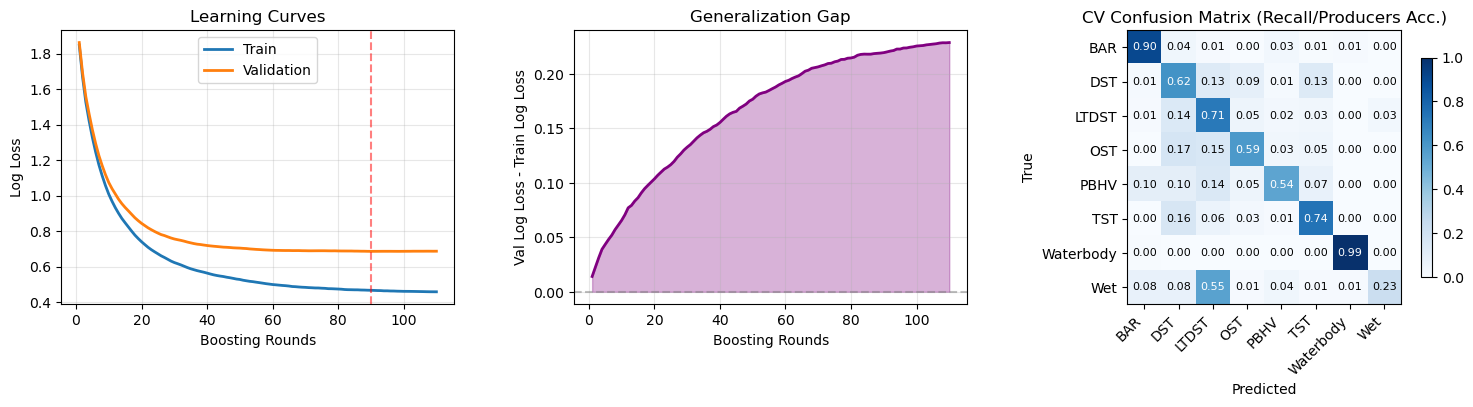

Final Train Log Loss: 0.4584
Final Val Log Loss: 0.6871
Generalization Gap: 0.2287
Best Val Log Loss: 0.6863 at epoch 90


In [129]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get metric name for labels
metric_name = LEARNING_CURVES.get('metric_name', 'Loss')

# Learning curves
ax1 = axes[0]
epochs = range(1, LEARNING_CURVES['n_estimators'] + 1)
ax1.plot(epochs, LEARNING_CURVES['train_error'], label='Train', linewidth=2)
ax1.plot(epochs, LEARNING_CURVES['val_error'], label='Validation', linewidth=2)
ax1.set_xlabel('Boosting Rounds')
ax1.set_ylabel(metric_name)
ax1.set_title('Learning Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

min_val_idx = np.argmin(LEARNING_CURVES['val_error'])
ax1.axvline(x=min_val_idx + 1, color='red', linestyle='--', alpha=0.5, label=f'Best val @ {min_val_idx+1}')

# Train-Val gap over time
ax2 = axes[1]
gap = np.array(LEARNING_CURVES['val_error']) - np.array(LEARNING_CURVES['train_error'])
ax2.plot(epochs, gap, color='purple', linewidth=2)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.fill_between(epochs, 0, gap, alpha=0.3, color='purple')
ax2.set_xlabel('Boosting Rounds')
ax2.set_ylabel(f'Val {metric_name} - Train {metric_name}')
ax2.set_title('Generalization Gap')
ax2.grid(True, alpha=0.3)

# Third plot: Confusion matrix (classification) or Predicted vs Actual scatter (regression)
ax3 = axes[2]

if PREDICTION_MODE == 'regression':
    # Scatter plot of predicted vs actual for regression
    ax3.scatter(y_val, val_pred, alpha=0.5, s=10, c='blue')
    
    # Add perfect prediction line
    val_min, val_max = min(y_val.min(), val_pred.min()), max(y_val.max(), val_pred.max())
    ax3.plot([val_min, val_max], [val_min, val_max], 'r--', linewidth=2, label='Perfect fit')
    
    ax3.set_xlabel('Actual')
    ax3.set_ylabel('Predicted')
    ax3.set_title(f'Predicted vs Actual (Val RÂ²={val_r2:.3f})')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Add text with metrics
    textstr = f'RMSE: {val_rmse:.4f}\nMAE: {mean_absolute_error(y_val, val_pred):.4f}\nRÂ²: {val_r2:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes, fontsize=9,
             verticalalignment='top', bbox=props)

else:
    # Confusion matrix heatmap for classification - using CV predictions on ORIGINAL distribution
    cm = confusion_matrix(y, y_pred_cv, labels=unique)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    im = ax3.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
    ax3.set_xticks(range(len(unique)))
    ax3.set_yticks(range(len(unique)))
    ax3.set_xticklabels([CLASS_NAMES[c] for c in unique], rotation=45, ha='right')
    ax3.set_yticklabels([CLASS_NAMES[c] for c in unique])
    ax3.set_xlabel('Predicted')
    ax3.set_ylabel('True')
    ax3.set_title('CV Confusion Matrix (Recall/Producers Acc.)')
    plt.colorbar(im, ax=ax3, shrink=0.8)
    
    for i in range(len(unique)):
        for j in range(len(unique)):
            color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
            ax3.text(j, i, f'{cm_normalized[i, j]:.2f}', ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
final_gap = LEARNING_CURVES['val_error'][-1] - LEARNING_CURVES['train_error'][-1]
print(f"Final Train {metric_name}: {LEARNING_CURVES['train_error'][-1]:.4f}")
print(f"Final Val {metric_name}: {LEARNING_CURVES['val_error'][-1]:.4f}")
print(f"Generalization Gap: {final_gap:.4f}")
print(f"Best Val {metric_name}: {min(LEARNING_CURVES['val_error']):.4f} at epoch {min_val_idx + 1}")

# Write learning_curves.csv
with open(CURVES_CSV_PATH, 'w', newline='') as _csvf:
    _writer = csv.writer(_csvf)
    _writer.writerow(['epoch', 'train_loss', 'val_loss', 'generalization_gap'])
    for _i in range(LEARNING_CURVES['n_estimators']):
        _tl = LEARNING_CURVES['train_error'][_i]
        _vl = LEARNING_CURVES['val_error'][_i]
        _writer.writerow([_i + 1, f"{_tl:.6f}", f"{_vl:.6f}", f"{_vl - _tl:.6f}"])

# Write confusion_matrix.csv (classification only)
if PREDICTION_MODE != 'regression':
    _cm = confusion_matrix(y, y_pred_cv, labels=unique)
    _class_labels = [CLASS_NAMES.get(c, f"Class_{c}") for c in unique]
    with open(CONFUSION_CSV_PATH, 'w', newline='') as _csvf:
        _writer = csv.writer(_csvf)
        _writer.writerow(['true_class'] + _class_labels)
        for _i, _cls in enumerate(unique):
            _writer.writerow([_class_labels[_i]] + [int(v) for v in _cm[_i]])

In [130]:
# Memory cleanup: free training/diagnostic arrays no longer needed
for _v in ['X', 'y', 'y_pred_cv', 'X_resampled', 'y_resampled',
           'X_train', 'X_val', 'y_train', 'y_val', 'clf_diagnostic',
           'train_pred', 'val_pred', 'full_train_pred']:
    if _v in dir():
        exec(f'del {_v}')
gc.collect()

24694

## 8. Predict on Full Imagery

Apply the trained model to predict on all valid pixels. Prediction is performed in chunks of  pixels to avoid out-of-memory errors on large images.

Supports loading features from separate prediction sources (e.g., a different image than the one used for training).

In [131]:
# =============================================================================
# LOAD PREDICTION DATA (IF SEPARATE FROM TRAINING)
# =============================================================================
# Check if any enabled dataset has a separate (non-timeseries) prediction source
has_separate_pred = any(
    has_separate_prediction_source(ds)
    for ds in INPUT_DATASETS
    if ds.get('enabled', True)
)

if has_separate_pred:
    print("Loading features from separate prediction sources...")
    pred_features, pred_feature_names = [], []

    for config in INPUT_DATASETS:
        if not config.get('enabled', True):
            continue

        ds_short = config.get('short', 'DS')

        # Load raw bands if configured
        bands = config.get('bands')
        if bands is not None and bands != []:
            try:
                da = load_dataset_native(config, reference_grid, source='prediction')
                if 'band' in da.dims:
                    for band in da.band.values:
                        pred_features.append(da.sel(band=band).drop_vars('band', errors='ignore'))
                        pred_feature_names.append(f"{ds_short}_band{band}")
                else:
                    pred_features.append(da.drop_vars('band', errors='ignore'))
                    pred_feature_names.append(f"{ds_short}_band1")
            except Exception as e:
                print(f"Failed to load bands from {config['name']}: {e}")

        # Calculate spectral indices if configured
        try:
            indices_data, indices_names = calculate_dataset_spectral_indices(
                config, reference_grid, source='prediction'
            )
            pred_features.extend(indices_data)
            pred_feature_names.extend(indices_names)
        except Exception as e:
            print(f"Failed to calculate indices for {config['name']}: {e}")

    # Verify feature names match training
    if pred_feature_names != feature_names:
        print(f"WARNING: Prediction feature names don't match training!")
        print(f"Training: {feature_names}")
        print(f"Prediction: {pred_feature_names}")

    # Stack prediction features
    pred_stacked = xr.Dataset({name: feat.squeeze() for name, feat in zip(pred_feature_names, pred_features)})
    pred_stacked = pred_stacked.rio.write_crs(NATIVE_CRS)

    pred_data = np.stack([pred_stacked[name].values for name in feature_names], axis=0)
    print(f"Loaded {len(pred_feature_names)} features from prediction sources")
else:
    # Use training data for prediction (existing behavior)
    pred_data = np.stack([stacked_ds[name].values for name in feature_names], axis=0)
n_bands, ny, nx = pred_data.shape
pixels = pred_data.reshape(n_bands, -1).T
del pred_data  # Free ~312 MB

valid_mask = ~np.isnan(pixels).any(axis=1)
pixels_to_predict = pixels[valid_mask]
del pixels  # Free ~312 MB
gc.collect()

predictions = np.full(ny * nx, np.nan, dtype=np.float32)

if valid_mask.sum() > 0:
    if PREDICTION_MODE == 'regression':
        # Regression: predict continuous values
        # Chunked prediction to avoid OOM
        n_valid = pixels_to_predict.shape[0]
        valid_predictions = np.empty(n_valid, dtype=np.float32)
        for start in range(0, n_valid, PREDICTION_CHUNK_SIZE):
            end = min(start + PREDICTION_CHUNK_SIZE, n_valid)
            valid_predictions[start:end] = clf.predict(pixels_to_predict[start:end]).astype(np.float32)
        predictions[valid_mask] = valid_predictions
        
        # Optional clipping
        clip_range = REGRESSION_CONFIG.get('clip_range')
        if clip_range is not None:
            min_val, max_val = clip_range
            clipped_count = ((predictions[valid_mask] < min_val) | (predictions[valid_mask] > max_val)).sum()
            predictions = np.clip(predictions, min_val, max_val)
            if clipped_count > 0:
                print(f"Clipped {clipped_count:,} predictions to range [{min_val}, {max_val}]")
    else:
        # Classification: predict class labels (1-indexed)
        # Chunked prediction to avoid OOM
        n_valid = pixels_to_predict.shape[0]
        valid_predictions = np.empty(n_valid, dtype=np.float32)
        for start in range(0, n_valid, PREDICTION_CHUNK_SIZE):
            end = min(start + PREDICTION_CHUNK_SIZE, n_valid)
            valid_predictions[start:end] = clf.predict(pixels_to_predict[start:end]).astype(np.float32)
        predictions[valid_mask] = valid_predictions + 1

prediction_da = xr.DataArray(
    predictions.reshape(ny, nx),
    dims=['y', 'x'],
    coords={'y': stacked_ds.coords['y'], 'x': stacked_ds.coords['x']},
    name='prediction'
).rio.write_crs(NATIVE_CRS)

# Log prediction stats
pred_log = [f"Valid pixels predicted: {valid_mask.sum():,} / {len(valid_mask):,}", ""]
pred_log.append(f"Prediction Mode: {PREDICTION_MODE}")

if PREDICTION_MODE == 'regression':
    valid_preds = predictions[~np.isnan(predictions)]
    pred_log.append("")
    pred_log.append("Predicted Value Distribution:")
    pred_log.append(f"  Min:    {valid_preds.min():.4f}")
    pred_log.append(f"  Max:    {valid_preds.max():.4f}")
    pred_log.append(f"  Mean:   {valid_preds.mean():.4f}")
    pred_log.append(f"  Std:    {valid_preds.std():.4f}")
    pred_log.append(f"  Median: {np.median(valid_preds):.4f}")
    if REGRESSION_CONFIG.get('clip_range'):
        pred_log.append(f"  Clip Range: {REGRESSION_CONFIG['clip_range']}")
else:
    pred_log.append("")
    pred_log.append("Predicted Class Distribution:")
    unique_classes = np.unique(predictions[~np.isnan(predictions)]).astype(int)
    for cls in unique_classes:
        count = (predictions == cls).sum()
        pred_log.append(f"  {CLASS_NAMES[cls-1]:12s}: {count:,} pixels")

log_section("PREDICTION", "\n".join(pred_log))

# Populate structured JSON: prediction results
_pred_results = {
    "valid_pixels": int(valid_mask.sum()),
    "total_pixels": int(len(valid_mask)),
    "mode": PREDICTION_MODE,
}
if PREDICTION_MODE == 'regression':
    _valid_preds = predictions[~np.isnan(predictions)]
    _pred_results["value_distribution"] = {
        "min": float(_valid_preds.min()),
        "max": float(_valid_preds.max()),
        "mean": float(_valid_preds.mean()),
        "std": float(_valid_preds.std()),
        "median": float(np.median(_valid_preds)),
    }
else:
    _class_dist_pred = {}
    _unique_pred = np.unique(predictions[~np.isnan(predictions)]).astype(int)
    for _cls in _unique_pred:
        _count = int((predictions == _cls).sum())
        _class_dist_pred[CLASS_NAMES.get(_cls - 1, f"Class_{_cls}")] = _count
    _pred_results["class_distribution"] = _class_dist_pred
RUN_LOG_JSON["results"]["prediction"] = _pred_results

print(f"Prediction complete. {valid_mask.sum():,} pixels {'regressed' if PREDICTION_MODE == 'regression' else 'classified'}.")

Prediction complete. 3,423,184 pixels classified.


In [132]:
# Memory cleanup: free prediction intermediates and feature stack
del predictions, stacked_ds
gc.collect()

126

## 9. Interactive Visualization

Reproject predictions to Web Mercator (EPSG:3857) and display as an interactive map with satellite basemap overlay. Hover over pixels to see predicted class or value.

In [133]:
print("Reprojecting to EPSG:3857 for visualization...")
prediction_wm = prediction_da.rio.reproject("EPSG:3857")

if PREDICTION_MODE == 'regression':
    # REGRESSION MODE: Continuous colormap visualization
    
    # Custom hover for continuous values
    hover = HoverTool(
        tooltips=[
            ('X', '$x{0.0}'), 
            ('Y', '$y{0.0}'), 
            ('Value', '@image{0.4f}')
        ]
    )
    
    # Get value range for colorbar
    valid_vals = prediction_wm.values[~np.isnan(prediction_wm.values)]
    vmin, vmax = np.percentile(valid_vals, [2, 98])  # Use percentiles to handle outliers
    
    img_plot = prediction_wm.hvplot.image(
        x='x', y='y', cmap='viridis', clim=(vmin, vmax), alpha=0.7,
        title=f'Predicted {VECTOR_TRAINING_CONFIG["target_column"]}',
        frame_width=700, frame_height=600,
        colorbar=True, rasterize=False
    ).opts(
        tools=[hover]
    )
    
    print(f"Value range (2nd-98th percentile): {vmin:.4f} to {vmax:.4f}")

else:
    # CLASSIFICATION MODE: Discrete class colormap visualization
    
    # Build class mapping for hover tooltip (dynamic based on CLASS_NAMES)
    class_js = ', '.join([f'{i+1}: "{name}"' for i, name in CLASS_NAMES.items()])
    class_name_formatter = CustomJSHover(code=f"""
        const class_names = {{{class_js}}};
        return class_names[Math.round(value)] || 'NoData';
    """)
    
    hover = HoverTool(
        tooltips=[('X', '$x{0.0}'), ('Y', '$y{0.0}'), ('Class', '@image{custom}')],
        formatters={'@image': class_name_formatter}
    )
    
    # Generate colors dynamically based on number of classes
    import colorsys
    n_classes = len(CLASS_NAMES)
    if n_classes <= 10:
        # Use predefined colors for up to 10 classes
        default_colors = ["#9C9C9C", "#F17E5B", "#43A043", "#2A5E08", "#A2DB97", 
                          "#8FB185", '#D2B48C', "#71BFFF", "#3FC9A6", '#A0522D']
        colors = default_colors[:n_classes]
    else:
        # Generate evenly spaced colors in HSV space for more classes
        colors = []
        for i in range(n_classes):
            hue = i / n_classes
            rgb = colorsys.hsv_to_rgb(hue, 0.7, 0.9)
            colors.append('#{:02x}{:02x}{:02x}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)))
    
    # Create colorbar tick labels with class names (dynamic)
    from bokeh.models import FixedTicker
    class_ticks = list(range(1, n_classes + 1))
    class_labels = {i+1: name for i, name in CLASS_NAMES.items()}
    
    img_plot = prediction_wm.hvplot.image(
        x='x', y='y', cmap=colors, clim=(0.5, n_classes + 0.5), alpha=0.3,
        title='Land Cover Prediction', frame_width=700, frame_height=600,
        colorbar=True, rasterize=False
    ).opts(
        tools=[hover],
        colorbar_opts={
            'ticker': FixedTicker(ticks=class_ticks),
            'major_label_overrides': class_labels
        }
    )

overlay = gvts.EsriImagery * img_plot
hv.output(overlay)

Reprojecting to EPSG:3857 for visualization...


:Overlay
   .WMTS.I  :WMTS   [Longitude,Latitude]
   .Image.I :Image   [x,y]   (prediction)

In [134]:
# Memory cleanup: free visualization reprojection
del prediction_wm
gc.collect()

76

## 10. Export to GeoTIFF

Save the prediction raster and a detailed run log:
- **Classification:** uint8 GeoTIFF with embedded colormap,  file for ArcGIS, and  run log
- **Regression:** float32 GeoTIFF with configurable NoData value

In [135]:
if PREDICTION_MODE == 'regression':
    # REGRESSION MODE: Export float32 raster with NoData
    output_dtype = REGRESSION_CONFIG.get('output_dtype', 'float32')
    output_nodata = REGRESSION_CONFIG.get('output_nodata', -9999)
    
    # Replace NaN with NoData value
    prediction_out = prediction_da.fillna(output_nodata).astype(output_dtype)
    prediction_out = prediction_out.rio.write_crs(prediction_da.rio.crs)
    prediction_out = prediction_out.rio.write_nodata(output_nodata)
    
    if os.path.exists(OUTPUT_PATH):
        os.remove(OUTPUT_PATH)
    
    prediction_out.rio.to_raster(OUTPUT_PATH, dtype=output_dtype)
    
    # Log output info
    output_log = [
        f"Output Folder: {RUN_OUTPUT_DIR}",
        f"Raster: {OUTPUT_PATH}",
        f"Learning Curves: {CURVES_PATH}",
        f"CRS: {prediction_da.rio.crs}",
        f"Dtype: {output_dtype}, NoData: {output_nodata}",
        f"Prediction Mode: REGRESSION",
        f"Target Column: {VECTOR_TRAINING_CONFIG['target_column']}"
    ]
    
    # Get value statistics
    valid_vals = prediction_da.values[~np.isnan(prediction_da.values)]
    output_log.append("")
    output_log.append("Output Value Statistics:")
    output_log.append(f"  Min:    {valid_vals.min():.4f}")
    output_log.append(f"  Max:    {valid_vals.max():.4f}")
    output_log.append(f"  Mean:   {valid_vals.mean():.4f}")
    
    print(f"Saved (regression): {OUTPUT_PATH}")

else:
    # CLASSIFICATION MODE: Export uint8 raster with colormap
    
    # Generate colormap dynamically based on number of classes
    import colorsys
    n_classes = len(CLASS_NAMES)
    
    # Default colors for up to 10 classes (original colors)
    default_rgba = [
        (0, 100, 0, 255),       # DST - dark green
        (144, 238, 144, 255),   # TST - light green
        (34, 139, 34, 255),     # LTDST - forest green
        (173, 255, 47, 255),    # OST - green yellow
        (0, 206, 209, 255),     # Wet - cyan
        (0, 0, 255, 255),       # Waterbody - blue
        (210, 180, 140, 255),   # PBHV - tan
        (128, 128, 128, 255),   # Barren - gray
        (139, 90, 43, 255),     # SASH - brown
        (160, 82, 45, 255),     # BRN - sienna
    ]
    
    COLORMAP = {0: (0, 0, 0, 0)}  # NoData
    
    if n_classes <= 10:
        # Use default colors
        for i in range(n_classes):
            COLORMAP[i + 1] = default_rgba[i]
    else:
        # Generate colors dynamically for more classes
        for i in range(n_classes):
            hue = i / n_classes
            rgb = colorsys.hsv_to_rgb(hue, 0.7, 0.9)
            COLORMAP[i + 1] = (int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255), 255)
    
    prediction_int = prediction_da.fillna(0).astype('uint8')
    prediction_int = prediction_int.rio.write_crs(prediction_da.rio.crs).rio.write_nodata(0)
    
    if os.path.exists(OUTPUT_PATH):
        os.remove(OUTPUT_PATH)
    
    prediction_int.rio.to_raster(OUTPUT_PATH, dtype='uint8')
    
    with rasterio.open(OUTPUT_PATH, 'r+') as dst:
        dst.write_colormap(1, COLORMAP)
        dst.colorinterp = [ColorInterp.palette]
    
    clr_path = OUTPUT_PATH.replace('.tif', '.clr')
    with open(clr_path, 'w') as f:
        for value, (r, g, b, a) in COLORMAP.items():
            class_name = CLASS_NAMES.get(value - 1, 'NoData') if value > 0 else 'NoData'
            f.write(f"{value} {r} {g} {b}  # {class_name}\n")
    
    # Log output info
    output_log = [
        f"Output Folder: {RUN_OUTPUT_DIR}",
        f"Raster: {OUTPUT_PATH}",
        f"Colormap: {clr_path}",
        f"Learning Curves: {CURVES_PATH}",
        f"CRS: {prediction_da.rio.crs}",
        f"Dtype: uint8, NoData: 0",
        f"Number of classes: {n_classes}",
        f"Prediction Mode: CLASSIFICATION"
    ]
    
    print(f"Saved (classification): {OUTPUT_PATH}")

log_section("OUTPUT", "\n".join(output_log))

# Write run log to file
with open(LOG_PATH, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write(f"XGBOOST {'REGRESSION' if PREDICTION_MODE == 'regression' else 'LAND COVER CLASSIFICATION'} RUN LOG\n")
    f.write("=" * 80 + "\n")
    f.write(f"Timestamp: {RUN_LOG['timestamp']}\n")
    f.write(f"Output: {OUTPUT_PATH}\n")
    f.write(f"Prediction Mode: {PREDICTION_MODE}\n")
    f.write(f"Training Data Mode: {TRAINING_DATA_MODE}\n")
    f.write("=" * 80 + "\n\n")
    
    for section in RUN_LOG['sections']:
        f.write(f"{'='*40}\n")
        f.write(f"{section['title']}\n")
        f.write(f"{'='*40}\n")
        f.write(section['content'] + "\n\n")

# Populate structured JSON: output
RUN_LOG_JSON["results"]["output"] = {
    "raster_path": OUTPUT_PATH,
    "crs": str(prediction_da.rio.crs),
    "dtype": "float32" if PREDICTION_MODE == "regression" else "uint8",
    "nodata": REGRESSION_CONFIG.get("output_nodata", -9999) if PREDICTION_MODE == "regression" else 0,
}

# Write structured JSON log
with open(JSON_LOG_PATH, 'w') as f:
    json_module.dump(RUN_LOG_JSON, f, indent=2, default=str)

print(f"Output folder: {RUN_OUTPUT_DIR}")
print(f"  Raster: {os.path.basename(OUTPUT_PATH)}")
print(f"  Log: {os.path.basename(LOG_PATH)}")
print(f"  JSON Log: {os.path.basename(JSON_LOG_PATH)}")
print(f"  Learning Curves CSV: {os.path.basename(CURVES_CSV_PATH)}")
if PREDICTION_MODE != 'regression':
    print(f"  Confusion Matrix CSV: {os.path.basename(CONFUSION_CSV_PATH)}")
    print(f"  Class Distribution CSV: {os.path.basename(CLASS_DIST_CSV_PATH)}")

Saved (classification): output/LC_FMNF_0213_1635/classified.tif
Output folder: output/LC_FMNF_0213_1635
  Raster: classified.tif
  Log: run_log.txt
  JSON Log: run_log.json
  Learning Curves CSV: learning_curves.csv
  Confusion Matrix CSV: confusion_matrix.csv
  Class Distribution CSV: class_distribution.csv


In [136]:
# Memory cleanup: free export array
for _v in ['prediction_int', 'prediction_out']:
    if _v in dir():
        exec(f'del {_v}')
gc.collect()

98

## 11. Time Series Prediction

Apply the trained model to multiple images from a time series folder. Supports two modes:

- **Single-dataset:** Predict on each image independently from one dataset's timeseries folder
- **Multi-dataset fusion:** Align images across datasets by year, stack features, and predict on the combined feature set

Configure time series via the  key in  with .

In [137]:
import gc

def extract_temporal_info(filename, dataset_config=None):
    """
    Extract year/date from filename with multi-pattern support.

    Supports multiple naming conventions:
    - Sentinel-2: S2*_MSIL2A_YYYYMMDD* -> extracts full date (day precision)
    - Annual composite: *_annual_YYYY_* -> extracts year (e.g. AlphaEarth embeddings)
    - Year-only suffix: *_YYYY.tif(f) or *-YYYY.tif(f) -> extracts year only

    Parameters:
    -----------
    filename : str
        The filename to parse
    dataset_config : dict, optional
        Dataset configuration (for future pattern customization)

    Returns:
    --------
    dict or None
        Dictionary with keys:
        - 'year': int, the year (always present if match found)
        - 'full_date': str or None, full date string if day precision available
        - 'date_str': str, string to use for output filenames
        - 'precision': str, 'day' or 'year'
        Returns None if no pattern matches
    """
    import re

    # Pattern 1: Sentinel-2 standard (MSIL2A_YYYYMMDD)
    match = re.search(r'MSIL2A_(\d{8})', filename)
    if match:
        date_str = match.group(1)
        return {
            'year': int(date_str[:4]),
            'full_date': date_str,
            'date_str': date_str,
            'precision': 'day'
        }

    # Pattern 2: Annual composite (*_annual_YYYY_*)
    match = re.search(r'_annual_(\d{4})_', filename)
    if match:
        year = match.group(1)
        return {
            'year': int(year),
            'full_date': None,
            'date_str': year,
            'precision': 'year'
        }

    # Pattern 3: Year-only suffix (*_YYYY.tif(f) or *-YYYY.tif(f))
    match = re.search(r'[_-](\d{4})\.tiff?$', filename, re.IGNORECASE)
    if match:
        year = match.group(1)
        return {
            'year': int(year),
            'full_date': None,
            'date_str': year,
            'precision': 'year'
        }

    return None


def discover_timeseries_files(timeseries_datasets):
    """
    Scan all timeseries datasets and discover available files with temporal info.

    Parameters:
    -----------
    timeseries_datasets : list
        List of dataset configurations with timeseries prediction enabled

    Returns:
    --------
    dict
        Dictionary containing:
        - 'datasets': dict mapping dataset short name to {
            'config': dataset config,
            'files_by_year': dict mapping year to file path,
            'available_years': set of years,
            'skipped_files': list of files that couldn't be parsed
          }
        - 'common_years': set of years present in ALL datasets
        - 'all_years': set of all years across all datasets
    """
    result = {
        'datasets': {},
        'common_years': None,
        'all_years': set()
    }

    for ds_config in timeseries_datasets:
        ds_short = ds_config.get('short', 'DS')
        pred_src = get_prediction_source(ds_config)

        # Find all matching files
        pattern_path = pred_src['path'] + pred_src['pattern']
        files = sorted(glob(pattern_path))

        files_by_year = {}
        skipped_files = []

        for filepath in files:
            filename = os.path.basename(filepath)
            temporal_info = extract_temporal_info(filename, ds_config)

            if temporal_info is None:
                skipped_files.append({
                    'file': filename,
                    'reason': 'Could not extract temporal info'
                })
                continue

            year = temporal_info['year']

            # Check for duplicate years (use first file found)
            if year in files_by_year:
                skipped_files.append({
                    'file': filename,
                    'reason': f'Duplicate year {year} (using {os.path.basename(files_by_year[year]["path"])})'
                })
                continue

            files_by_year[year] = {
                'path': filepath,
                'filename': filename,
                'temporal_info': temporal_info
            }

        available_years = set(files_by_year.keys())

        result['datasets'][ds_short] = {
            'config': ds_config,
            'files_by_year': files_by_year,
            'available_years': available_years,
            'skipped_files': skipped_files
        }

        result['all_years'].update(available_years)

        # Update common years (intersection)
        if result['common_years'] is None:
            result['common_years'] = available_years.copy()
        else:
            result['common_years'] &= available_years

    return result


def report_temporal_alignment(discovery_result, timeseries_datasets):
    """
    Print a detailed report of temporal alignment across datasets.

    Parameters:
    -----------
    discovery_result : dict
        Output from discover_timeseries_files()
    timeseries_datasets : list
        Original list of dataset configurations
    """
    print("\n" + "-" * 50)
    print("TEMPORAL ALIGNMENT REPORT")
    print("-" * 50)

    # Per-dataset summary
    for ds_config in timeseries_datasets:
        ds_short = ds_config.get('short', 'DS')
        ds_name = ds_config.get('name', ds_short)
        ds_info = discovery_result['datasets'].get(ds_short, {})

        available_years = sorted(ds_info.get('available_years', set()))
        skipped = ds_info.get('skipped_files', [])

        print(f"\n{ds_name} ({ds_short}):")
        print(f"  Available years: {available_years if available_years else 'None'}")
        print(f"  Total files: {len(ds_info.get('files_by_year', {}))}")
        if skipped:
            print(f"  Skipped files: {len(skipped)}")
            for skip in skipped[:3]:  # Show first 3
                print(f"    - {skip['file']}: {skip['reason']}")
            if len(skipped) > 3:
                print(f"    ... and {len(skipped) - 3} more")

    # Common years analysis
    common_years = sorted(discovery_result['common_years']) if discovery_result['common_years'] else []
    all_years = sorted(discovery_result['all_years'])

    print(f"\n{'=' * 50}")
    print(f"COMMON YEARS (will be processed): {common_years if common_years else 'NONE'}")
    print(f"{'=' * 50}")

    # Show which years are skipped and why
    skipped_years = set(all_years) - set(common_years)
    if skipped_years:
        print(f"\nSkipped years (missing from one or more datasets):")
        for year in sorted(skipped_years):
            missing_from = []
            for ds_short, ds_info in discovery_result['datasets'].items():
                if year not in ds_info['available_years']:
                    missing_from.append(ds_short)
            print(f"  {year}: missing from {', '.join(missing_from)}")

    print("-" * 50)


def extract_multi_dataset_features_for_year(year, discovery_result, reference_da, all_feature_names):
    """
    Extract and combine features from all datasets for a given year.

    Parameters:
    -----------
    year : int
        The year to process
    discovery_result : dict
        Output from discover_timeseries_files()
    reference_da : xarray.DataArray
        Reference grid for alignment
    all_feature_names : list
        Complete list of feature names expected by the model (in order)

    Returns:
    --------
    tuple
        (combined_features: xr.Dataset, date_str: str, success: bool, error_msg: str)
        - combined_features: Dataset with all features, or None on failure
        - date_str: String to use for output filename
        - success: True if all features extracted successfully
        - error_msg: Error message if failed, empty string if success
    """
    combined_features = {}
    date_str = str(year)  # Default to year, may be updated to full date

    for ds_short, ds_info in discovery_result['datasets'].items():
        ds_config = ds_info['config']
        file_info = ds_info['files_by_year'].get(year)

        if file_info is None:
            return None, date_str, False, f"No file for year {year} in dataset {ds_short}"

        # Update date_str if we have day precision (prefer more precise dates)
        if file_info['temporal_info']['precision'] == 'day':
            date_str = file_info['temporal_info']['date_str']

        # Get expected feature names for this dataset
        ds_feature_names = get_dataset_feature_names(ds_config)

        try:
            # Extract features from this dataset's file
            ts_features, ts_feature_names = extract_features_from_timeseries_image(
                file_info['path'],
                ds_config,
                reference_da,
                ds_feature_names
            )

            if ts_features is None:
                return None, date_str, False, f"Failed to extract features from {file_info['filename']}"

            # Verify feature names match
            if ts_feature_names != ds_feature_names:
                return None, date_str, False, (
                    f"Feature mismatch for {ds_short}: "
                    f"expected {ds_feature_names}, got {ts_feature_names}"
                )

            # Add features to combined dict
            for name in ts_feature_names:
                combined_features[name] = ts_features[name]

        except Exception as e:
            return None, date_str, False, f"Error processing {file_info['filename']}: {str(e)}"

    # Verify all expected features are present
    missing_features = set(all_feature_names) - set(combined_features.keys())
    if missing_features:
        return None, date_str, False, f"Missing features: {missing_features}"

    extra_features = set(combined_features.keys()) - set(all_feature_names)
    if extra_features:
        # Extra features from timeseries datasets are ignored (not needed by model)
        print(f"    Note: Ignoring {len(extra_features)} extra features not used by model: {extra_features}")

    # Create combined dataset with features in correct order
    combined_ds = xr.Dataset({name: combined_features[name] for name in all_feature_names})
    combined_ds = combined_ds.rio.write_crs(reference_da.rio.crs)

    return combined_ds, date_str, True, ""


def predict_multi_dataset_timeseries(clf, timeseries_datasets, all_feature_names, output_folder,
                                     colormap, class_names, prediction_mode, reference_da,
                                     regression_config=None):
    """
    Run timeseries prediction with temporal alignment across multiple datasets.

    Only processes years where ALL enabled timeseries datasets have data.

    Parameters:
    -----------
    clf : XGBClassifier or XGBRegressor
        Trained model
    timeseries_datasets : list
        List of dataset configurations with timeseries prediction enabled
    all_feature_names : list
        Complete list of feature names expected by the model
    output_folder : str
        Output folder for predictions
    colormap : dict
        Color mapping for classification output
    class_names : dict
        Class name mapping
    prediction_mode : str
        'classification' or 'regression'
    reference_da : xarray.DataArray
        Reference grid from training data
    regression_config : dict, optional
        Regression output settings

    Returns:
    --------
    tuple
        (processed: list, failed: list, skipped_years: list)
    """
    # Discover files and find common years
    discovery = discover_timeseries_files(timeseries_datasets)

    # Print alignment report
    report_temporal_alignment(discovery, timeseries_datasets)

    # Check for common years
    if not discovery['common_years']:
        print("\nERROR: No common years found across all datasets!")
        print("Cannot proceed with multi-dataset timeseries prediction.")
        return [], [], list(discovery['all_years'])

    common_years = sorted(discovery['common_years'])
    print(f"\nProcessing {len(common_years)} common years: {common_years}")

    processed = []
    failed = []

    for year in common_years:
        print(f"\n  Year {year}:")

        # Extract combined features
        combined_features, date_str, success, error_msg = extract_multi_dataset_features_for_year(
            year, discovery, reference_da, all_feature_names
        )

        if not success:
            print(f"    FAILED: {error_msg}")
            failed.append({
                'year': year,
                'date_str': date_str,
                'reason': error_msg
            })
            continue

        # Show which files are being combined
        for ds_short, ds_info in discovery['datasets'].items():
            file_info = ds_info['files_by_year'].get(year)
            if file_info:
                print(f"    {ds_short}: {file_info['filename']}")

        try:
            # Prepare data for prediction (column-by-column to avoid full .T copy)
            sample = combined_features[all_feature_names[0]].values.squeeze()
            ny, nx = sample.shape
            n_pixels = ny * nx
            n_bands = len(all_feature_names)

            # Build valid mask incrementally
            valid_mask = np.ones(n_pixels, dtype=bool)
            for name in all_feature_names:
                band_flat = combined_features[name].values.squeeze().ravel()
                valid_mask &= ~np.isnan(band_flat)

            # Only allocate the valid-pixel subset
            n_valid = int(valid_mask.sum())
            pixels_to_predict = np.empty((n_valid, n_bands), dtype=np.float32)
            for i, name in enumerate(all_feature_names):
                band_flat = combined_features[name].values.squeeze().ravel()
                pixels_to_predict[:, i] = band_flat[valid_mask]

            predictions = np.full(ny * nx, np.nan, dtype=np.float32)

            if valid_mask.sum() > 0:
                if prediction_mode == 'regression':
                    # Chunked prediction to avoid OOM
                    n_valid = pixels_to_predict.shape[0]
                    valid_predictions = np.empty(n_valid, dtype=np.float32)
                    for start in range(0, n_valid, PREDICTION_CHUNK_SIZE):
                        end = min(start + PREDICTION_CHUNK_SIZE, n_valid)
                        valid_predictions[start:end] = clf.predict(pixels_to_predict[start:end]).astype(np.float32)
                    predictions[valid_mask] = valid_predictions

                    if regression_config and regression_config.get('clip_range'):
                        min_val, max_val = regression_config['clip_range']
                        predictions = np.clip(predictions, min_val, max_val)
                else:
                    # Chunked prediction to avoid OOM
                    n_valid = pixels_to_predict.shape[0]
                    valid_predictions = np.empty(n_valid, dtype=np.float32)
                    for start in range(0, n_valid, PREDICTION_CHUNK_SIZE):
                        end = min(start + PREDICTION_CHUNK_SIZE, n_valid)
                        valid_predictions[start:end] = clf.predict(pixels_to_predict[start:end]).astype(np.float32)
                    predictions[valid_mask] = valid_predictions + 1

            # Create prediction DataArray
            prediction_da = xr.DataArray(
                predictions.reshape(ny, nx),
                dims=['y', 'x'],
                coords={'y': combined_features.coords['y'], 'x': combined_features.coords['x']},
                name='prediction'
            ).rio.write_crs(reference_da.rio.crs)

            # Save output
            output_filename = f"LC_{date_str}.tif"
            output_path = os.path.join(output_folder, output_filename)

            if prediction_mode == 'regression':
                output_dtype = regression_config.get('output_dtype', 'float32') if regression_config else 'float32'
                output_nodata = regression_config.get('output_nodata', -9999) if regression_config else -9999

                prediction_out = prediction_da.fillna(output_nodata).astype(output_dtype)
                prediction_out = prediction_out.rio.write_crs(prediction_da.rio.crs)
                prediction_out = prediction_out.rio.write_nodata(output_nodata)

                prediction_out.rio.to_raster(output_path, dtype=output_dtype)
            else:
                prediction_int = prediction_da.fillna(0).astype('uint8')
                prediction_int = prediction_int.rio.write_crs(prediction_da.rio.crs)
                prediction_int = prediction_int.rio.write_nodata(0)

                prediction_int.rio.to_raster(output_path, dtype='uint8')

                with rasterio.open(output_path, 'r+') as dst:
                    dst.write_colormap(1, colormap)
                    dst.colorinterp = [ColorInterp.palette]

            valid_count = int(valid_mask.sum())
            print(f"    Saved: {output_filename} ({valid_count:,} valid pixels)")

            processed.append({
                'year': year,
                'date_str': date_str,
                'output': output_filename,
                'valid_pixels': valid_count
            })

            del combined_features, pixels_to_predict, valid_mask, predictions, prediction_da
            gc.collect()

        except Exception as e:
            print(f"    ERROR: {e}")
            gc.collect()
            failed.append({
                'year': year,
                'date_str': date_str,
                'reason': str(e)
            })

    skipped_years = sorted(discovery['all_years'] - discovery['common_years'])
    return processed, failed, skipped_years


def extract_features_from_timeseries_image(image_path, dataset_config, reference_da, feature_names_expected):
    """
    Load a timeseries image and extract features matching the training configuration.

    Parameters:
    -----------
    image_path : str
        Path to the timeseries image
    dataset_config : dict
        Single dataset configuration with prediction.is_timeseries=True
    reference_da : xarray.DataArray
        Reference grid for alignment (from training data)
    feature_names_expected : list
        Expected feature names from this dataset (for validation)

    Returns:
    --------
    xarray.Dataset
        Dataset with features matching the training configuration
    list
        Feature names in same order as training
    """
    # Load the timeseries image (load() to read into memory and release file handle)
    ts_da = xr.open_dataarray(image_path, engine='rasterio').load()

    # Apply nodata masking if specified
    if 'nodata' in dataset_config:
        ts_da = ts_da.where(ts_da != dataset_config['nodata'])

    # Reproject to match reference grid if needed
    if ts_da.rio.crs != reference_da.rio.crs or ts_da.shape[-2:] != reference_da.shape[-2:]:
        ts_da = ts_da.rio.reproject_match(reference_da, resampling=Resampling.bilinear)

    all_features = []
    feature_names_out = []
    ds_short = dataset_config.get('short', 'DS')

    # Extract raw bands if configured
    bands = dataset_config.get('bands')
    if bands is not None and bands != []:
        if 'band' in ts_da.dims:
            for band in bands:
                if band in ts_da.band.values:
                    all_features.append(ts_da.sel(band=band).drop_vars('band', errors='ignore'))
                    feature_names_out.append(f"{ds_short}_band{band}")
                else:
                    print(f"    Warning: Band {band} not found in timeseries image")
                    return None, None
        else:
            all_features.append(ts_da.drop_vars('band', errors='ignore'))
            feature_names_out.append(f"{ds_short}_band1")

    # Calculate spectral indices if configured
    si_config = dataset_config.get('spectral_indices', {})
    if si_config.get('enabled', False):
        indices_config = si_config.get('indices', {})
        enabled_indices = {name: cfg for name, cfg in indices_config.items()
                         if cfg.get('enabled', True)}

        for idx_name, idx_config in enabled_indices.items():
            try:
                result = compute_spectral_index(ts_da, idx_config)
                all_features.append(result)
                feature_names_out.append(f"{ds_short}_{idx_name}")
            except Exception as e:
                print(f"    Warning: Failed to compute {idx_name}: {e}")
                return None, None

    if not all_features:
        return None, None

    # Stack into dataset
    stacked = xr.Dataset({name: feat.squeeze() for name, feat in zip(feature_names_out, all_features)})
    stacked = stacked.rio.write_crs(reference_da.rio.crs)

    return stacked, feature_names_out


def predict_timeseries_for_dataset(clf, feature_names, dataset_config, all_feature_names,
                                   output_folder, colormap, class_names, prediction_mode,
                                   reference_da, regression_config=None):
    """
    Apply trained model to all images in timeseries folder for a single dataset.

    Parameters:
    -----------
    clf : XGBClassifier or XGBRegressor
        Trained model
    feature_names : list
        List of feature names from this dataset (subset of all_feature_names)
    dataset_config : dict
        Dataset configuration with prediction.is_timeseries=True
    all_feature_names : list
        Full list of feature names in order expected by model
    output_folder : str
        Output folder path for timeseries predictions
    colormap : dict
        Color mapping for classification output
    class_names : dict
        Class name mapping
    prediction_mode : str
        'classification' or 'regression'
    reference_da : xarray.DataArray
        Reference grid from training data
    regression_config : dict, optional
        Regression output settings

    Returns:
    --------
    tuple
        (list of processed image info dicts, list of failed image info dicts)
    """
    # Get prediction source
    pred_src = get_prediction_source(dataset_config)
    timeseries_folder = pred_src['path']
    timeseries_pattern = pred_src['pattern']

    # Find all matching files
    pattern_path = timeseries_folder + timeseries_pattern
    timeseries_files = sorted(glob(pattern_path))

    if not timeseries_files:
        print(f"No files found matching: {pattern_path}")
        return [], []

    print(f"Found {len(timeseries_files)} timeseries images")

    processed = []
    failed = []

    for ts_file in timeseries_files:
        filename = os.path.basename(ts_file)
        temporal_info = extract_temporal_info(filename, dataset_config)

        if temporal_info is None:
            print(f"  Skipping {filename}: Could not extract temporal info")
            failed.append({'file': filename, 'reason': 'Could not extract temporal info'})
            continue

        date_str = temporal_info['date_str']
        print(f"  Processing: {filename} (date: {date_str})")

        try:
            # Extract features from timeseries image
            ts_features, ts_feature_names = extract_features_from_timeseries_image(
                ts_file, dataset_config, reference_da, feature_names
            )

            if ts_features is None:
                print(f"    Skipping: Failed to extract features")
                failed.append({'file': filename, 'reason': 'Failed to extract features'})
                continue

            # Verify feature names match training (for this dataset's features)
            if ts_feature_names != feature_names:
                print(f"    Warning: Feature names mismatch")
                print(f"    Expected: {feature_names}")
                print(f"    Got: {ts_feature_names}")
                failed.append({'file': filename, 'reason': 'Feature names mismatch'})
                continue

            # For single-dataset mode, all features must come from this dataset
            if feature_names != all_feature_names:
                print(f"    Warning: Multi-dataset timeseries not supported in single-dataset mode")
                print(f"    This dataset provides: {feature_names}")
                print(f"    Model expects: {all_feature_names}")
                failed.append({'file': filename, 'reason': 'Multi-dataset timeseries not supported'})
                continue

            # Prepare data for prediction (column-by-column to avoid full .T copy)
            sample = ts_features[feature_names[0]].values.squeeze()
            ny, nx = sample.shape
            n_pixels = ny * nx
            n_bands = len(feature_names)

            # Build valid mask incrementally
            valid_mask = np.ones(n_pixels, dtype=bool)
            for name in feature_names:
                band_flat = ts_features[name].values.squeeze().ravel()
                valid_mask &= ~np.isnan(band_flat)

            # Only allocate the valid-pixel subset
            n_valid = int(valid_mask.sum())
            pixels_to_predict = np.empty((n_valid, n_bands), dtype=np.float32)
            for i, name in enumerate(feature_names):
                band_flat = ts_features[name].values.squeeze().ravel()
                pixels_to_predict[:, i] = band_flat[valid_mask]

            predictions = np.full(ny * nx, np.nan, dtype=np.float32)

            if valid_mask.sum() > 0:
                if prediction_mode == 'regression':
                    # Chunked prediction to avoid OOM
                    n_valid = pixels_to_predict.shape[0]
                    valid_predictions = np.empty(n_valid, dtype=np.float32)
                    for start in range(0, n_valid, PREDICTION_CHUNK_SIZE):
                        end = min(start + PREDICTION_CHUNK_SIZE, n_valid)
                        valid_predictions[start:end] = clf.predict(pixels_to_predict[start:end]).astype(np.float32)
                    predictions[valid_mask] = valid_predictions

                    # Optional clipping
                    if regression_config and regression_config.get('clip_range'):
                        min_val, max_val = regression_config['clip_range']
                        predictions = np.clip(predictions, min_val, max_val)
                else:
                    # Chunked prediction to avoid OOM
                    n_valid = pixels_to_predict.shape[0]
                    valid_predictions = np.empty(n_valid, dtype=np.float32)
                    for start in range(0, n_valid, PREDICTION_CHUNK_SIZE):
                        end = min(start + PREDICTION_CHUNK_SIZE, n_valid)
                        valid_predictions[start:end] = clf.predict(pixels_to_predict[start:end]).astype(np.float32)
                    predictions[valid_mask] = valid_predictions + 1

            # Create prediction DataArray
            prediction_da_ts = xr.DataArray(
                predictions.reshape(ny, nx),
                dims=['y', 'x'],
                coords={'y': ts_features.coords['y'], 'x': ts_features.coords['x']},
                name='prediction'
            ).rio.write_crs(reference_da.rio.crs)

            # Save output
            output_filename = f"LC_{date_str}.tif"
            output_path = os.path.join(output_folder, output_filename)

            if prediction_mode == 'regression':
                output_dtype = regression_config.get('output_dtype', 'float32') if regression_config else 'float32'
                output_nodata = regression_config.get('output_nodata', -9999) if regression_config else -9999

                prediction_out = prediction_da_ts.fillna(output_nodata).astype(output_dtype)
                prediction_out = prediction_out.rio.write_crs(prediction_da_ts.rio.crs)
                prediction_out = prediction_out.rio.write_nodata(output_nodata)

                prediction_out.rio.to_raster(output_path, dtype=output_dtype)
            else:
                prediction_int = prediction_da_ts.fillna(0).astype('uint8')
                prediction_int = prediction_int.rio.write_crs(prediction_da_ts.rio.crs)
                prediction_int = prediction_int.rio.write_nodata(0)

                prediction_int.rio.to_raster(output_path, dtype='uint8')

                # Add colormap
                with rasterio.open(output_path, 'r+') as dst:
                    dst.write_colormap(1, colormap)
                    dst.colorinterp = [ColorInterp.palette]

            valid_count = int(valid_mask.sum())
            print(f"    Saved: {output_filename} ({valid_count:,} valid pixels)")

            processed.append({
                'file': filename,
                'date': date_str,
                'output': output_filename,
                'valid_pixels': valid_count
            })

            # Clear memory
            del ts_features, pixels_to_predict, valid_mask, predictions, prediction_da_ts
            gc.collect()

        except Exception as e:
            print(f"    Error: {e}")
            failed.append({'file': filename, 'reason': str(e)})
            gc.collect()
            continue

    return processed, failed


def get_dataset_feature_names(config):
    """
    Get the list of feature names that a dataset will produce.

    Parameters:
    -----------
    config : dict
        Dataset configuration

    Returns:
    --------
    list
        Feature names this dataset produces (bands + indices)
    """
    names = []
    ds_short = config.get('short', 'DS')

    # Raw bands
    bands = config.get('bands')
    if bands is not None and bands != []:
        for band in bands:
            names.append(f"{ds_short}_band{band}")

    # Spectral indices
    si_config = config.get('spectral_indices', {})
    if si_config.get('enabled', False):
        indices_config = si_config.get('indices', {})
        for idx_name, idx_cfg in indices_config.items():
            if idx_cfg.get('enabled', True):
                names.append(f"{ds_short}_{idx_name}")

    return names


# =============================================================================
# RUN TIME SERIES PREDICTION
# =============================================================================
# Find datasets with timeseries prediction configured
timeseries_datasets = [
    ds for ds in INPUT_DATASETS
    if ds.get('enabled', True) and has_timeseries_prediction(ds)
]

if timeseries_datasets:
    print("\n" + "=" * 60)
    print("TIME SERIES PREDICTION")
    print("=" * 60)

    # Check if we have multiple datasets (use multi-dataset fusion mode)
    if len(timeseries_datasets) > 1:
        # Multi-dataset fusion mode with temporal alignment
        print(f"\nMulti-dataset mode: {len(timeseries_datasets)} timeseries datasets")
        for ds in timeseries_datasets:
            print(f"  - {ds.get('name', ds.get('short', 'unknown'))}")

        # Create output folder for fused predictions
        timeseries_output = os.path.join(RUN_OUTPUT_DIR, 'timeseries', 'fused')
        os.makedirs(timeseries_output, exist_ok=True)
        print(f"\nOutput: {timeseries_output}")

        # Run multi-dataset prediction with temporal alignment
        processed_images, failed_images, skipped_years = predict_multi_dataset_timeseries(
            clf=clf,
            timeseries_datasets=timeseries_datasets,
            all_feature_names=feature_names,
            output_folder=timeseries_output,
            colormap=COLORMAP,
            class_names=CLASS_NAMES,
            prediction_mode=PREDICTION_MODE,
            reference_da=reference_grid,
            regression_config=REGRESSION_CONFIG if PREDICTION_MODE == 'regression' else None
        )

        # Summary
        print()
        print("=" * 50)
        print("Multi-dataset time series prediction complete!")
        print(f"  Years processed: {len(processed_images)}")
        print(f"  Years failed: {len(failed_images)}")
        print(f"  Years skipped (missing data): {len(skipped_years)}")

        # Log results
        ts_log = [
            "MODE: Multi-dataset fusion",
            f"Datasets: {[ds.get('short', 'DS') for ds in timeseries_datasets]}",
            f"Years processed: {len(processed_images)}",
            f"Years failed: {len(failed_images)}",
            f"Years skipped: {len(skipped_years)} ({skipped_years})",
            "",
            "Processed years:"
        ]

        for img in processed_images:
            ts_log.append(f"  - {img['year']} -> {img['output']} ({img['valid_pixels']:,} valid pixels)")

        if failed_images:
            ts_log.append("")
            ts_log.append("Failed years:")
            for img in failed_images:
                ts_log.append(f"  - {img['year']}: {img['reason']}")

        log_section("TIME SERIES PREDICTION", "\n".join(ts_log))

        with open(LOG_PATH, 'a') as f:
            f.write("\n" + "=" * 40 + "\n")
            f.write("TIME SERIES PREDICTION - Multi-dataset\n")
            f.write("=" * 40 + "\n")
            f.write("\n".join(ts_log) + "\n")

        print(f"\nTimeseries outputs saved to: {timeseries_output}")

    else:
        # Single dataset mode - use existing behavior
        for ts_config in timeseries_datasets:
            ds_name = ts_config.get('name', ts_config.get('short', 'unknown'))
            pred_src = get_prediction_source(ts_config)

            print(f"\nDataset: {ds_name}")
            print(f"Timeseries folder: {pred_src['path']}")
            print(f"Pattern: {pred_src['pattern']}")

            # Create timeseries output subfolder
            timeseries_output = os.path.join(RUN_OUTPUT_DIR, 'timeseries', ts_config.get('short', 'TS'))
            os.makedirs(timeseries_output, exist_ok=True)
            print(f"Output: {timeseries_output}")
            print()

            # Get feature names for this dataset
            ds_feature_names = get_dataset_feature_names(ts_config)

            # Run timeseries prediction
            processed_images, failed_images = predict_timeseries_for_dataset(
                clf=clf,
                feature_names=ds_feature_names,
                dataset_config=ts_config,
                all_feature_names=feature_names,
                output_folder=timeseries_output,
                colormap=COLORMAP,
                class_names=CLASS_NAMES,
                prediction_mode=PREDICTION_MODE,
                reference_da=reference_grid,
                regression_config=REGRESSION_CONFIG if PREDICTION_MODE == 'regression' else None
            )

            # Summary
            print()
            print(f"Time series prediction complete for {ds_name}!")
            print(f"  Successfully processed: {len(processed_images)}")
            print(f"  Failed: {len(failed_images)}")

            # Log timeseries results
            ts_log = [
                f"Dataset: {ds_name}",
                f"Timeseries folder: {pred_src['path']}",
                f"Pattern: {pred_src['pattern']}",
                f"Images found: {len(processed_images) + len(failed_images)}",
                f"Successfully processed: {len(processed_images)}",
                f"Failed: {len(failed_images)}",
                "",
                "Processed images:"
            ]

            for img in processed_images:
                ts_log.append(f"  - {img['file']} -> {img['output']} ({img['valid_pixels']:,} valid pixels)")

            if failed_images:
                ts_log.append("")
                ts_log.append("Failed images:")
                for img in failed_images:
                    ts_log.append(f"  - {img['file']}: {img['reason']}")

            log_section("TIME SERIES PREDICTION", "\n".join(ts_log))

            # Update the run log file with timeseries info
            with open(LOG_PATH, 'a') as f:
                f.write("\n" + "=" * 40 + "\n")
                f.write(f"TIME SERIES PREDICTION - {ds_name}\n")
                f.write("=" * 40 + "\n")
                f.write("\n".join(ts_log) + "\n")

            print(f"\nTimeseries outputs saved to: {timeseries_output}")
else:
    print("\nTime series prediction: No datasets configured with timeseries prediction")


Time series prediction: No datasets configured with timeseries prediction
